# CSE 475 - Assignment 01
## Group Information

| Field | Details |
|-------------------------|-------------------------------------|
| **Group ID** | Group G |
| **Student 1 Name** | Aditya Debnath |
| **Student 1 ID** | 2022-2-60-124 |
| **Student 2 Name** | Umme Habiba |
| **Student 2 ID** | 2022-1-60-362 |
| **Student 3 Name** | Purnendu Bhowmik Shuvro |
| **Student 3 ID** | 2023-1-60-085 |
| **Student 4 Name** | Mujahida Nazmoon Naher |
| **Student 4 ID** | 2022-2-60-099 |
| **Notebook Type** | CNN Models / Transformer Models |
| **Dataset Source Name** | Chilli dataset |
| **Dataset Source Link** | https://data.mendeley.com/datasets/tf9dtfz9m6/2 |
| **Kaggle Dataset Path** | /kaggle/input/datasets/adityadebnathtirtha/chilli-dataset-2024/Chilli Dataset 2024 |
| **Submission Date** | 30 March 2026 |

## 📋 Table of Contents
1. [⚙️ Global Configuration](#config)
2. [📦 Setup & Imports](#setup)
3. [📊 Exploratory Data Analysis](#eda)
4. [🔧 Data Preprocessing, Augmentation & Split](#preprocessing)
5. [🏋️ Training Infrastructure](#training)
6. [🟣 Transformer Models: ViT · Swin · DeiT](#transformers)
7. [📈 Evaluation & Comparison](#evaluation)
8. [🛡️ Robustness Analysis](#robustness)
9. [🔍 Error Analysis with Attention Maps](#error)
10. [📝 Cross-Architecture Comparison Report](#report)


## ⚙️ Global Configuration <a id='config'></a>
**All hyperparameters, paths, seeds, and toggles are defined here. No hardcoded values appear elsewhere.**

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║           GLOBAL CONFIGURATION — EDIT THIS CELL ONLY         ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, re

# ── Reproducibility ─────────────────────────────────────────────────
SEED = 42

# ── Dataset Path ────────────────────────────────────────────────────
BASE_DIR   = '/kaggle/input/datasets/adityadebnathtirtha/chilli-dataset-2024/Chilli Dataset 2024'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def safe_name(s): return re.sub(r'[^A-Za-z0-9._-]+', '_', str(s)).strip('_')

# ── Data Split Ratios ───────────────────────────────────────────────
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

# ── Image settings ──────────────────────────────────────────────────
IMG_SIZE   = 224     # ViT/Swin/DeiT all support 224×224

# ── Training ────────────────────────────────────────────────────────
BATCH_SIZE      = 32    # Reduce to 16 if CUDA OOM
NUM_EPOCHS      = 30    
FREEZE_EPOCHS   = 15     # Frozen backbone phase before full fine-tune
EARLY_STOP_PAT  = 7     # Early-stopping patience

# ── Optimizer — AdamW (standard for transformers) ───────────────────
TF_LR_HEAD      = 1e-3   # Head-only LR (frozen phase)
TF_LR_FULL      = 1e-4   # Full fine-tune LR (recommended for ViTs)
WEIGHT_DECAY    = 0.05   # Higher WD is standard for ViT
GRAD_CLIP       = 1.0

# ── Warmup + Cosine schedule ────────────────────────────────────────
WARMUP_EPOCHS   = 3      # Linear warmup before cosine decay

# ── Loss & regularisation ───────────────────────────────────────────
LABEL_SMOOTHING   = 0.1
USE_CLASS_WEIGHTS = True
DROPOUT_RATE      = 0.1  # ViTs use lower dropout than CNNs
MIXUP_ALPHA       = 0.2

# ── Augmentation ────────────────────────────────────────────────────
RANDAUG_OPS     = 2
RANDAUG_MAG     = 9
RANDOM_ERASE_P  = 0.25   # Higher erasing for transformers (they need it)

# ── Robustness ──────────────────────────────────────────────────────
NOISE_LEVELS    = [0.05, 0.15]
BLUR_KERNELS    = [3, 9]

# ── Transformer model IDs (timm) ────────────────────────────────────
TRANSFORMER_MODELS = {
    'ViT-B/16'  : 'vit_base_patch16_224',
    'Swin-Tiny' : 'swin_tiny_patch4_window7_224',
    'DeiT-Small': 'deit_small_patch16_224',
}

# ── Pretrained weights ──────────────────────────────────────────────
USE_PRETRAINED = True    # Required for fine-tuning

# ── Display ─────────────────────────────────────────────────────────
COLORS  = ['#E74C3C','#F39C12','#8E44AD','#27AE60','#3498DB','#1ABC9C',
           '#E67E22','#2ECC71','#9B59B6','#34495E']
FIGDPI  = 120
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("✅ Global Configuration loaded.")
print(f"   Split → Train:{TRAIN_RATIO:.0%}  Val:{VAL_RATIO:.0%}  Test:{TEST_RATIO:.0%}")
print(f"   IMG_SIZE={IMG_SIZE}  BATCH={BATCH_SIZE}  EPOCHS={NUM_EPOCHS}")
print(f"   Optimizer: AdamW  LR_head={TF_LR_HEAD:.0e}  LR_full={TF_LR_FULL:.0e}")
print(f"   Warmup: {WARMUP_EPOCHS} epochs  WD={WEIGHT_DECAY}  Grad-clip={GRAD_CLIP}")
print(f"   Fine-tune: freeze {FREEZE_EPOCHS} epochs → unfreeze all (cosine LR)")
print(f"   Early-stop patience: {EARLY_STOP_PAT} epochs")
print(f"\nTransformer Models:")
for name, tid in TRANSFORMER_MODELS.items():
    print(f"   {name:<15} → timm id: '{tid}'")


✅ Global Configuration loaded.
   Split → Train:80%  Val:10%  Test:10%
   IMG_SIZE=224  BATCH=32  EPOCHS=30
   Optimizer: AdamW  LR_head=1e-03  LR_full=1e-04
   Warmup: 3 epochs  WD=0.05  Grad-clip=1.0
   Fine-tune: freeze 15 epochs → unfreeze all (cosine LR)
   Early-stop patience: 7 epochs

Transformer Models:
   ViT-B/16        → timm id: 'vit_base_patch16_224'
   Swin-Tiny       → timm id: 'swin_tiny_patch4_window7_224'
   DeiT-Small      → timm id: 'deit_small_patch16_224'


## 📦 Setup & Imports <a id='setup'></a>

In [2]:
!pip install timm grad-cam -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.7 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import os, random, time, warnings, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from torchvision import transforms
import timm
from timm.models.vision_transformer import VisionTransformer

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve, auc,
    precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"\n📦 PyTorch {torch.__version__} | timm {timm.__version__}")


🖥️  Device : cuda
   GPU    : Tesla T4
   VRAM   : 15.6 GB

📦 PyTorch 2.10.0+cu128 | timm 1.0.25


## 📊 Exploratory Data Analysis <a id='eda'></a>

### 📌 Dataset Acknowledgement
> **Dataset Name**: *[Dataset name — chilli dataset]*  
> **Source**: *[Official URL —  https://data.mendeley.com/datasets/tf9dtfz9m6/2]*  
> This dataset is used strictly for educational and research purposes.

---
**Additional transformer-specific EDA consideration:**  
ViT/DeiT/Swin tokenise images into fixed-size **patches** (16×16 px default).  
An input of 224×224 yields **196 tokens** (14×14 grid) per image.  
Class complexity visible in EDA helps us reason about whether 196 tokens are sufficient to capture discriminative structure.


In [4]:
# ── Discover all images ──────────────────────────────────────────────
EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

def discover_all_images(base_dir):
    base, records = Path(base_dir), []
    subdirs    = [d for d in base.iterdir() if d.is_dir()]
    sub_names  = {d.name for d in subdirs}
    split_keys = {'train','test','val','valid','validation','Train','Test','Val'}
    if sub_names and sub_names.issubset(split_keys):
        for sd in subdirs:
            for cd in sd.iterdir():
                if cd.is_dir():
                    for f in cd.iterdir():
                        if f.suffix.lower() in EXTS:
                            records.append((str(f), cd.name))
    else:
        for cd in subdirs:
            for f in cd.iterdir():
                if f.suffix.lower() in EXTS:
                    records.append((str(f), cd.name))
    return records

all_records = discover_all_images(BASE_DIR)
CLASS_NAMES = sorted(set(r[1] for r in all_records))
NUM_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}
short = [c[:15] for c in CLASS_NAMES]

print(f"✅ Total images: {len(all_records)}")
print(f"📂 {NUM_CLASSES} classes:")
for i, c in enumerate(CLASS_NAMES):
    cnt = sum(1 for r in all_records if r[1] == c)
    print(f"   [{i}] {c:<30} — {cnt} images")


✅ Total images: 10987
📂 5 classes:
   [0] cercospora                     — 2219 images
   [1] healthy                        — 2198 images
   [2] mites_and_trips                — 2507 images
   [3] nutritional                    — 2032 images
   [4] powdery mildew                 — 2031 images


In [5]:
# ── Stratified 80/10/10 split ────────────────────────────────────────
all_paths  = [r[0] for r in all_records]
all_labels = [CLASS_TO_IDX[r[1]] for r in all_records]

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=(VAL_RATIO+TEST_RATIO), random_state=SEED, stratify=all_labels)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=TEST_RATIO/(VAL_RATIO+TEST_RATIO), random_state=SEED, stratify=temp_labels)

print(f"📊 Dataset split (stratified):")
print(f"   Train : {len(train_paths):>5}  ({len(train_paths)/len(all_paths):.1%})")
print(f"   Val   : {len(val_paths):>5}  ({len(val_paths)/len(all_paths):.1%})")
print(f"   Test  : {len(test_paths):>5}  ({len(test_paths)/len(all_paths):.1%})")

# Class-wise stats
split_stats = []
for cls in CLASS_NAMES:
    idx = CLASS_TO_IDX[cls]
    tr = sum(1 for l in train_labels if l == idx)
    vl = sum(1 for l in val_labels   if l == idx)
    te = sum(1 for l in test_labels  if l == idx)
    split_stats.append({'Class': cls, 'Train': tr, 'Val': vl, 'Test': te, 'Total': tr+vl+te})
stats_df = pd.DataFrame(split_stats)
print("\nClass-wise split:")
print(stats_df[['Class','Train','Val','Test','Total']].to_string(index=False))


📊 Dataset split (stratified):
   Train :  8789  (80.0%)
   Val   :  1099  (10.0%)
   Test  :  1099  (10.0%)

Class-wise split:
          Class  Train  Val  Test  Total
     cercospora   1775  222   222   2219
        healthy   1758  220   220   2198
mites_and_trips   2005  251   251   2507
    nutritional   1626  203   203   2032
 powdery mildew   1625  203   203   2031


In [6]:
# ── Verify no data leakage between splits ────────────────────────────
train_set = set(train_paths)
val_set   = set(val_paths)
test_set  = set(test_paths)

overlap_train_test = train_set & test_set
overlap_train_val  = train_set & val_set
overlap_val_test   = val_set  & test_set

print(f"\nTrain ∩ Test : {len(overlap_train_test)}  ← must be 0")
print(f"Train ∩ Val  : {len(overlap_train_val)}   ← must be 0")
print(f"Val   ∩ Test : {len(overlap_val_test)}    ← must be 0")

if len(overlap_train_test) == 0 and len(overlap_train_val) == 0 and len(overlap_val_test) == 0:
    print("✅ No data leakage — splits are clean")
else:
    print("❌ DATA LEAKAGE DETECTED — splits overlap!")
    print("   Re-run your split cell with a fixed random seed")


Train ∩ Test : 0  ← must be 0
Train ∩ Val  : 0   ← must be 0
Val   ∩ Test : 0    ← must be 0
✅ No data leakage — splits are clean


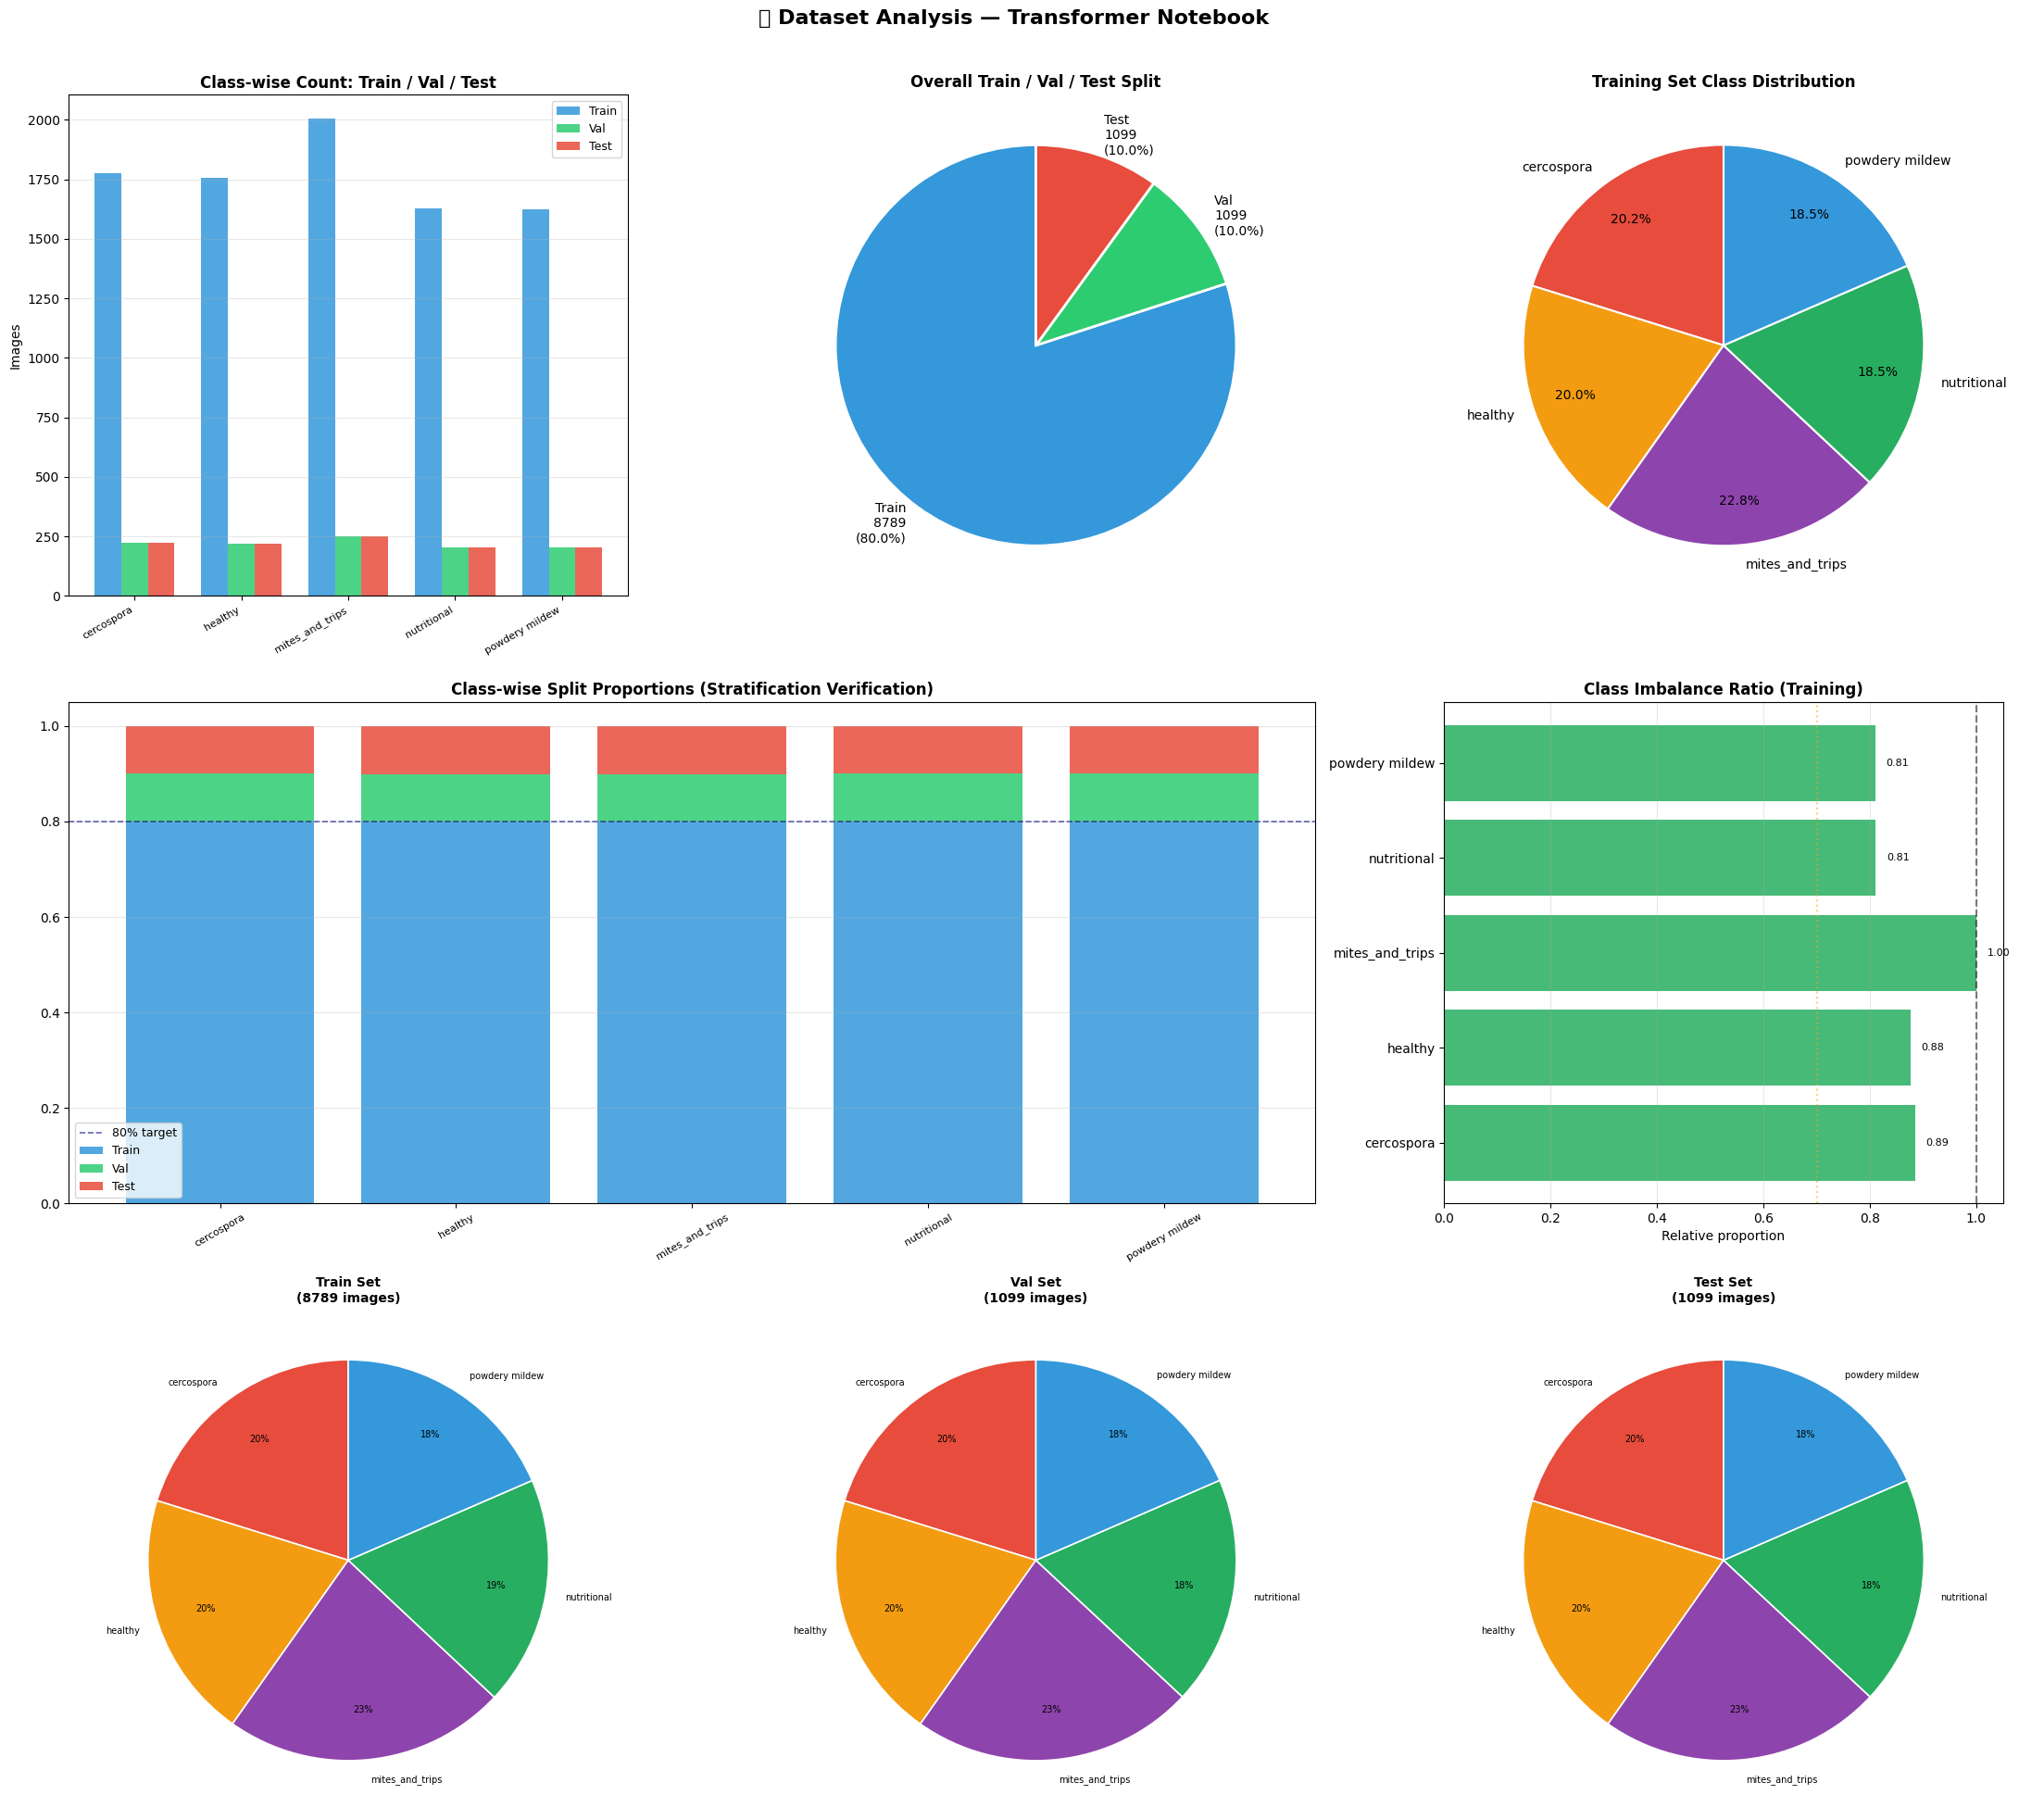

In [7]:
# ── Rich EDA with pie charts and bar charts ──────────────────────────
fig = plt.figure(figsize=(22, 20))
fig.suptitle('📊 Dataset Analysis — Transformer Notebook', fontsize=16, fontweight='bold', y=0.98)
ccolors = [COLORS[i % len(COLORS)] for i in range(NUM_CLASSES)]

# Row 1 col 1: Grouped bar train/val/test
ax1 = fig.add_subplot(3, 3, 1)
x, w = np.arange(NUM_CLASSES), 0.25
ax1.bar(x-w, stats_df['Train'], w, color='#3498DB', alpha=0.85, label='Train')
ax1.bar(x,   stats_df['Val'],   w, color='#2ECC71', alpha=0.85, label='Val')
ax1.bar(x+w, stats_df['Test'],  w, color='#E74C3C', alpha=0.85, label='Test')
ax1.set_xticks(x); ax1.set_xticklabels(short, rotation=30, ha='right', fontsize=8)
ax1.set_title('Class-wise Count: Train / Val / Test', fontweight='bold')
ax1.set_ylabel('Images'); ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

# Row 1 col 2: Pie — overall split
ax2 = fig.add_subplot(3, 3, 2)
split_labels = [f'Train\n{len(train_paths)}\n({len(train_paths)/len(all_paths):.1%})',
                f'Val\n{len(val_paths)}\n({len(val_paths)/len(all_paths):.1%})',
                f'Test\n{len(test_paths)}\n({len(test_paths)/len(all_paths):.1%})']
ax2.pie([len(train_paths), len(val_paths), len(test_paths)],
        labels=split_labels, colors=['#3498DB','#2ECC71','#E74C3C'],
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('Overall Train / Val / Test Split', fontweight='bold')

# Row 1 col 3: Pie — training class dist
ax3 = fig.add_subplot(3, 3, 3)
ax3.pie(stats_df['Train'], labels=short, colors=ccolors,
        autopct='%1.1f%%', startangle=90, pctdistance=0.78,
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax3.set_title('Training Set Class Distribution', fontweight='bold')

# Row 2: Stacked bar (proportions) + Imbalance
ax4 = fig.add_subplot(3, 3, (4, 5))
totals   = stats_df['Total'].values
tr_frac  = stats_df['Train'].values / totals
vl_frac  = stats_df['Val'].values   / totals
te_frac  = stats_df['Test'].values  / totals
ax4.bar(short, tr_frac, color='#3498DB', alpha=0.85, label='Train')
ax4.bar(short, vl_frac, bottom=tr_frac, color='#2ECC71', alpha=0.85, label='Val')
ax4.bar(short, te_frac, bottom=tr_frac+vl_frac, color='#E74C3C', alpha=0.85, label='Test')
ax4.axhline(TRAIN_RATIO, color='navy', ls='--', lw=1.2, alpha=0.6, label=f'{TRAIN_RATIO:.0%} target')
ax4.set_title('Class-wise Split Proportions (Stratification Verification)', fontweight='bold')
ax4.tick_params(axis='x', rotation=30, labelsize=8); ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.3)

ax5 = fig.add_subplot(3, 3, 6)
ratio   = stats_df['Train'].values / stats_df['Train'].max()
icolors = ['#27AE60' if r>0.7 else ('#F39C12' if r>0.4 else '#E74C3C') for r in ratio]
hbars   = ax5.barh(short, ratio, color=icolors, alpha=0.85)
ax5.axvline(1.0, color='k', ls='--', alpha=0.5); ax5.axvline(0.7, color='orange', ls=':', alpha=0.5)
ax5.set_xlabel('Relative proportion'); ax5.set_title('Class Imbalance Ratio (Training)', fontweight='bold')
ax5.grid(axis='x', alpha=0.3)
for bar, v in zip(hbars, ratio):
    ax5.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2, f'{v:.2f}', va='center', fontsize=8)

# Row 3: Separate pies for train/val/test
for col, (sname, slbls) in enumerate([('Train', train_labels),
                                        ('Val',   val_labels),
                                        ('Test',  test_labels)]):
    ax = fig.add_subplot(3, 3, 7 + col)
    counts_s = [sum(1 for l in slbls if l==i) for i in range(NUM_CLASSES)]
    ax.pie(counts_s, labels=short, colors=ccolors, autopct='%1.0f%%',
           startangle=90, pctdistance=0.75, textprops={'fontsize':7},
           wedgeprops=dict(edgecolor='white', linewidth=1.2))
    ax.set_title(f'{sname} Set\n({sum(counts_s)} images)', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'{OUTPUT_DIR}/eda_distribution_tf.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()


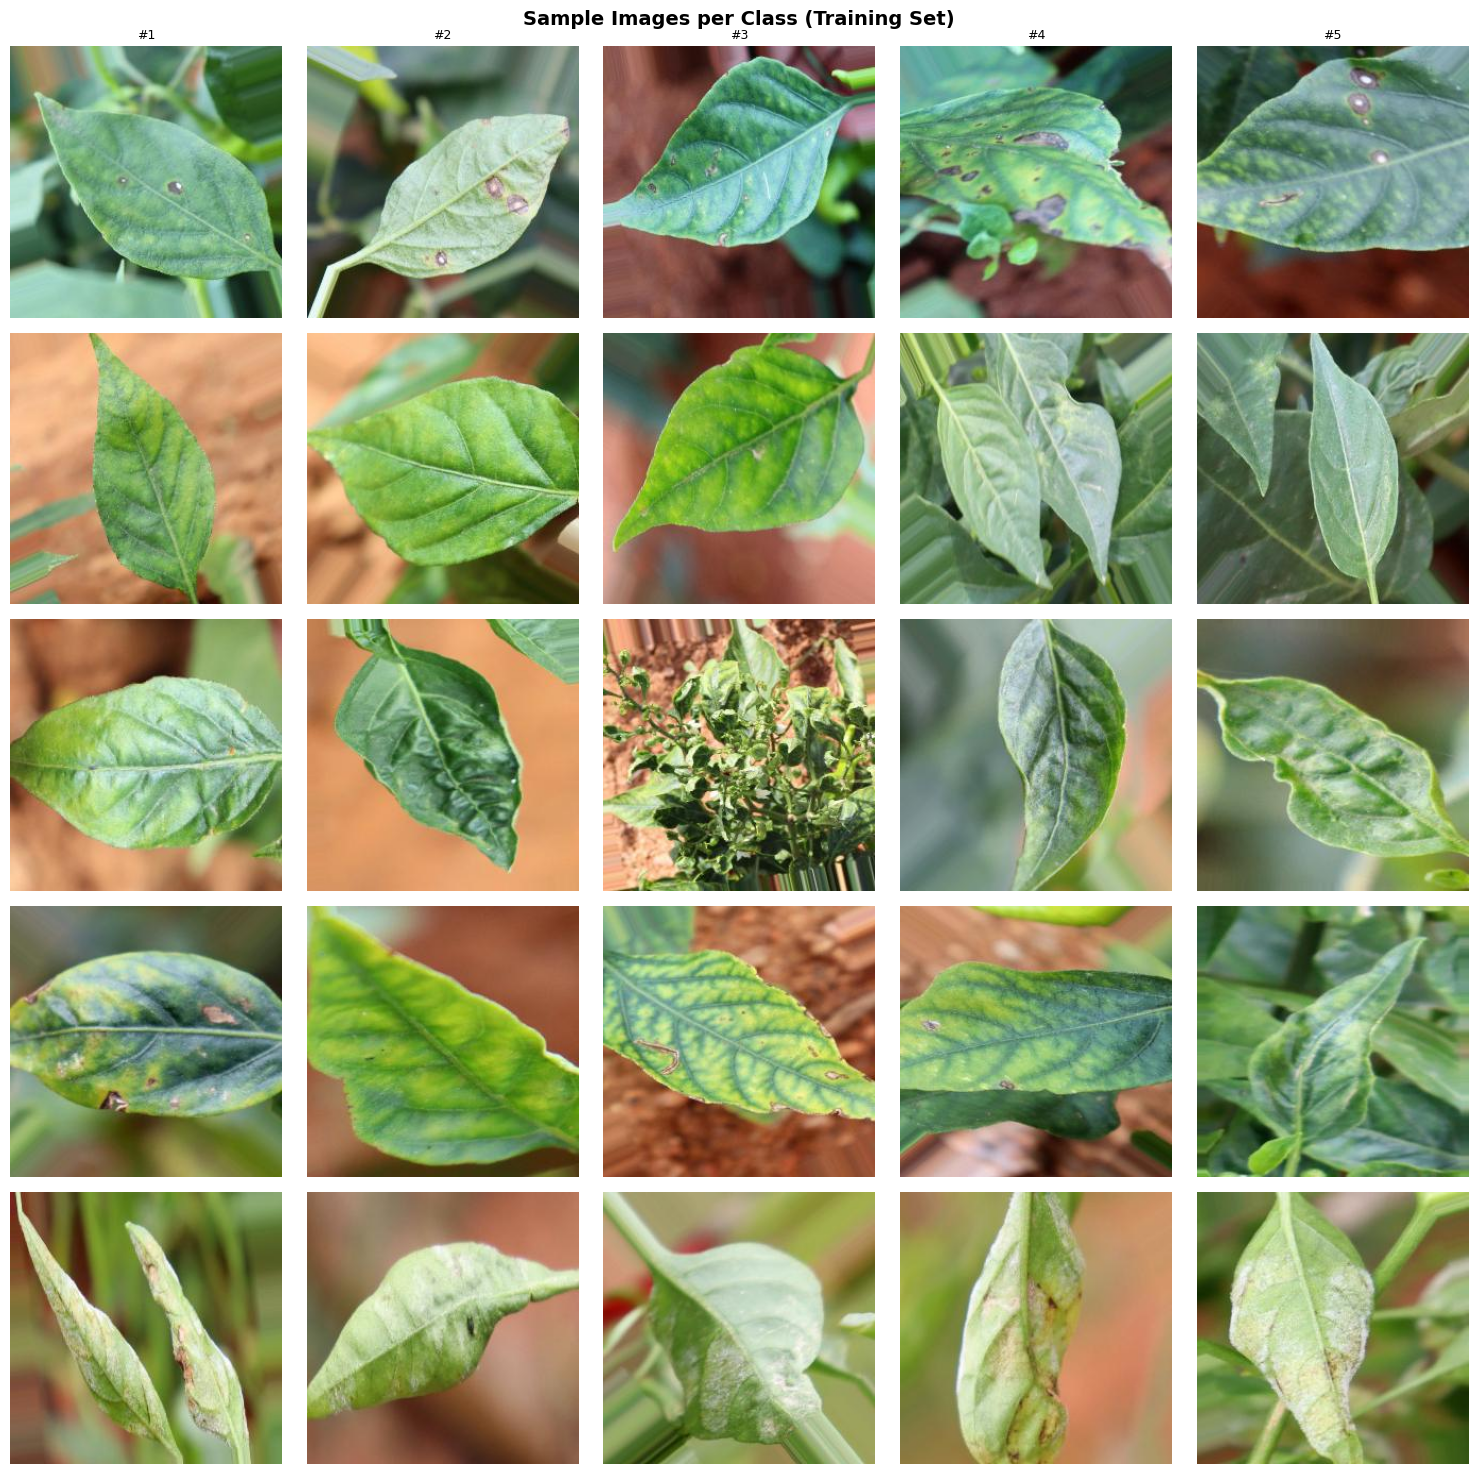

In [8]:
# ── Sample images per class ──────────────────────────────────────────
def sample_imgs_from_list(paths, labels, class_idx, n=5):
    idxs   = [i for i, l in enumerate(labels) if l == class_idx]
    chosen = random.sample(idxs, min(n, len(idxs)))
    return [paths[i] for i in chosen]

N = 5
fig, axes = plt.subplots(NUM_CLASSES, N, figsize=(N*3, NUM_CLASSES*3))
if NUM_CLASSES == 1: axes = [axes]
fig.suptitle('Sample Images per Class (Training Set)', fontsize=14, fontweight='bold')
for r, cls in enumerate(CLASS_NAMES):
    row_axes = axes[r] if NUM_CLASSES > 1 else axes
    for c, p in enumerate(sample_imgs_from_list(train_paths, train_labels, CLASS_TO_IDX[cls], N)):
        row_axes[c].imshow(Image.open(p).convert('RGB'))
        row_axes[c].axis('off')
        if c == 0:
            row_axes[c].set_ylabel(cls[:20], fontsize=8, labelpad=55, rotation=0,
                                    ha='right', va='center',
                                    color=COLORS[r%len(COLORS)], fontweight='bold')
        if r == 0: row_axes[c].set_title(f'#{c+1}', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_images_tf.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()


⏳ Analysing image properties...


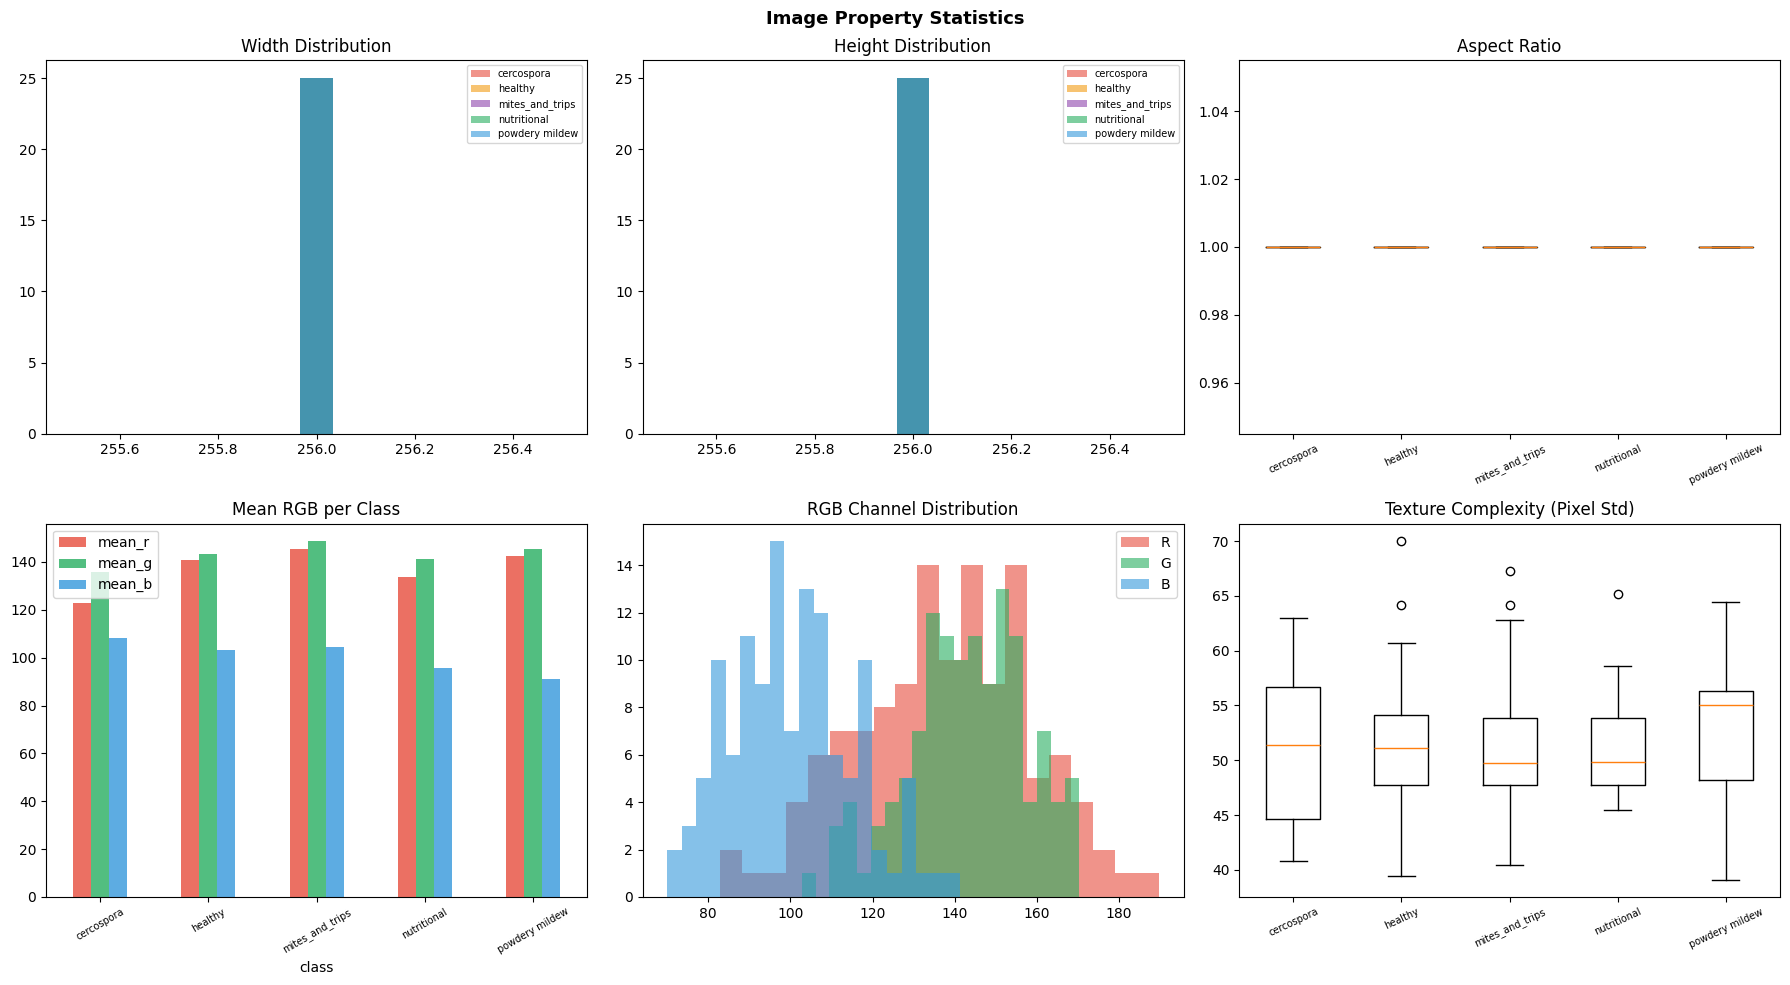


Avg resolution: 256×256px → resized to 224×224

🔢 ViT Tokenisation (patch_size=16):
   224×224 → 14×14 = 196 patches (tokens)
   Each patch encodes a 16×16×3 = 768 dimensional raw input
   Patches are projected to d_model dimensional embedding vectors

💡 Dataset characteristics relevance:
   • Image complexity (Std=51.7) determines whether
     196 tokens are sufficient for discrimination
   • Class separability via colour (RGB per class) may help or hinder
     attention — high colour separation → fewer tokens needed for focus


In [9]:
# ── Image statistics + ViT tokenisation discussion ───────────────────
print("⏳ Analysing image properties...")
records_dim = []
for cls in CLASS_NAMES:
    for p in sample_imgs_from_list(train_paths, train_labels, CLASS_TO_IDX[cls], 25):
        try:
            img = Image.open(p).convert('RGB')
            arr = np.array(img)
            records_dim.append({'class': cls,
                'width': img.size[0], 'height': img.size[1],
                'aspect': img.size[0]/img.size[1],
                'mean_r': arr[:,:,0].mean(), 'mean_g': arr[:,:,1].mean(),
                'mean_b': arr[:,:,2].mean(), 'std': arr.std()})
        except: pass
props = pd.DataFrame(records_dim)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Image Property Statistics', fontsize=13, fontweight='bold')
for i, cls in enumerate(CLASS_NAMES):
    sub = props[props['class']==cls]
    axes[0,0].hist(sub['width'],  alpha=0.6, color=COLORS[i%len(COLORS)], label=short[i], bins=15)
    axes[0,1].hist(sub['height'], alpha=0.6, color=COLORS[i%len(COLORS)], label=short[i], bins=15)
axes[0,0].set_title('Width Distribution');  axes[0,0].legend(fontsize=7)
axes[0,1].set_title('Height Distribution'); axes[0,1].legend(fontsize=7)
axes[0,2].boxplot([props[props['class']==c]['aspect'].values for c in CLASS_NAMES], labels=short)
axes[0,2].set_title('Aspect Ratio'); axes[0,2].tick_params(axis='x', rotation=25, labelsize=7)
props.groupby('class')[['mean_r','mean_g','mean_b']].mean().plot(
    kind='bar', ax=axes[1,0], color=['#E74C3C','#27AE60','#3498DB'], alpha=0.8)
axes[1,0].set_title('Mean RGB per Class'); axes[1,0].tick_params(axis='x', rotation=30, labelsize=7)
for i,(ch,col) in enumerate(zip(['mean_r','mean_g','mean_b'],['#E74C3C','#27AE60','#3498DB'])):
    axes[1,1].hist(props[ch], alpha=0.6, color=col, label=['R','G','B'][i], bins=20)
axes[1,1].set_title('RGB Channel Distribution'); axes[1,1].legend()
axes[1,2].boxplot([props[props['class']==c]['std'].values for c in CLASS_NAMES], labels=short)
axes[1,2].set_title('Texture Complexity (Pixel Std)'); axes[1,2].tick_params(axis='x', rotation=25, labelsize=7)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/image_properties_tf.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()

avg_w, avg_h = props['width'].mean(), props['height'].mean()
n_tokens = (IMG_SIZE // 16) ** 2
print(f"\nAvg resolution: {avg_w:.0f}×{avg_h:.0f}px → resized to {IMG_SIZE}×{IMG_SIZE}")
print(f"\n🔢 ViT Tokenisation (patch_size=16):")
print(f"   {IMG_SIZE}×{IMG_SIZE} → {IMG_SIZE//16}×{IMG_SIZE//16} = {n_tokens} patches (tokens)")
print(f"   Each patch encodes a {16}×{16}×3 = {16*16*3} dimensional raw input")
print(f"   Patches are projected to d_model dimensional embedding vectors")
print(f"\n💡 Dataset characteristics relevance:")
print(f"   • Image complexity (Std={props['std'].mean():.1f}) determines whether")
print(f"     {n_tokens} tokens are sufficient for discrimination")
print(f"   • Class separability via colour (RGB per class) may help or hinder")
print(f"     attention — high colour separation → fewer tokens needed for focus")


## 🔧 Data Preprocessing, Augmentation & Split <a id='preprocessing'></a>

**Transformer-specific augmentation rationale:**

| Transform | Why for Transformers? |
|-----------|----------------------|
| `Resize(224)` | All ViT/Swin/DeiT models require fixed 224×224 input |
| `RandomHorizontalFlip` | Standard spatial invariance |
| `ColorJitter` | Colour domain robustness |
| `RandAugment` | Strong policy augmentation shown to improve ViT training (DeiT paper) |
| `RandomErasing(p=0.25)` | Higher erasing probability — transformers benefit more from this than CNNs |
| `MixUp(α=0.2)` | Label-mixing regularisation, used in both DeiT and Swin training |

**AdamW with weight decay=0.05** is standard for all ViT variants (higher WD than CNNs because transformers are more overfit-prone on small datasets).

**Linear warmup + cosine schedule** is the canonical transformer LR strategy, preventing instability in the first few epochs.


In [10]:
# ── Custom Dataset ───────────────────────────────────────────────────
class PathDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]


# ── Transforms ───────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandAugment(num_ops=RANDAUG_OPS, magnitude=RANDAUG_MAG),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=RANDOM_ERASE_P, scale=(0.02, 0.33)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = PathDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = PathDataset(val_paths,   val_labels,   transform=val_transform)
test_dataset  = PathDataset(test_paths,  test_labels,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

counts_arr  = np.array([sum(1 for l in train_labels if l==i)
                         for i in range(NUM_CLASSES)], dtype=float)
class_weights = (1.0/counts_arr) / (1.0/counts_arr).sum() * NUM_CLASSES

# When defining CW_TENSOR, ensure it's float:
CW_TENSOR = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print(f"✅ Train: {len(train_dataset):>5} | {len(train_loader):>3} batches")
print(f"✅ Val  : {len(val_dataset):>5} | {len(val_loader):>3} batches")
print(f"✅ Test : {len(test_dataset):>5} | {len(test_loader):>3} batches")
print(f"⚖️  Class weights: {class_weights.round(3)}")


✅ Train:  8789 | 274 batches
✅ Val  :  1099 |  35 batches
✅ Test :  1099 |  35 batches
⚖️  Class weights: [0.984 0.994 0.872 1.075 1.075]


## 🏋️ Training Infrastructure <a id='training'></a>

**Transformer-specific training stack:**
- **AdamW** with weight decay=0.05 (decoupled weight decay, as per the paper)
- **Linear warmup** for the first `WARMUP_EPOCHS` epochs — critical to prevent early training instability
- **CosineAnnealing** LR decay after warmup
- **Mixed-precision training** with `torch.cuda.amp` — reduces VRAM usage and speeds up forward/backward passes
- **Gradient clipping** at norm=1.0 — especially important for ViT which can have large gradient spikes
- **Early stopping** on validation accuracy

In [11]:
# ── Loss & MixUp helpers ─────────────────────────────────────────────
def build_criterion():
    return nn.CrossEntropyLoss(
        weight=CW_TENSOR if USE_CLASS_WEIGHTS else None,
        label_smoothing=LABEL_SMOOTHING)

def mixup_batch(images, labels, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return images, F.one_hot(labels, NUM_CLASSES).float()
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0))
    mixed = lam * images + (1-lam) * images[idx]
    y_a = F.one_hot(labels,      NUM_CLASSES).float()
    y_b = F.one_hot(labels[idx], NUM_CLASSES).float()
    return mixed, lam*y_a + (1-lam)*y_b

def soft_cross_entropy(logits, soft_targets):
    log_prob = F.log_softmax(logits, dim=1)
    if USE_CLASS_WEIGHTS:
        w = CW_TENSOR / CW_TENSOR.sum()
        return -(soft_targets * log_prob * w.unsqueeze(0)).sum(1).mean()
    return -(soft_targets * log_prob).sum(1).mean()


# ── Warmup + Cosine LR scheduler ────────────────────────────────────
class WarmupCosineScheduler:
    """Linear warmup for warmup_steps, then cosine decay to eta_min."""    
    def __init__(self, optimizer, warmup_epochs, total_epochs,
                 eta_min_ratio=0.01, last_epoch=-1):
        self.opt     = optimizer
        self.warmup  = warmup_epochs
        self.total   = total_epochs
        self.eta_min = eta_min_ratio
        self.base_lrs= [g['lr'] for g in optimizer.param_groups]
        self.ep      = 0

    def step(self):
        self.ep += 1
        if self.ep <= self.warmup:
            factor = self.ep / max(1, self.warmup)
        else:
            progress = (self.ep - self.warmup) / max(1, self.total - self.warmup)
            factor   = self.eta_min + 0.5*(1-self.eta_min)*(1 + math.cos(math.pi*progress))
        for g, base in zip(self.opt.param_groups, self.base_lrs):
            g['lr'] = base * factor

    def get_lr(self):
        return [g['lr'] for g in self.opt.param_groups][0]


# ── Mixed-precision training epoch ───────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


def train_epoch(model, loader, criterion, optimizer, scaler, use_mixup=True):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE).long() 
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():           # ✅ AMP context
            if use_mixup and MIXUP_ALPHA > 0:
                mixed_imgs, soft_labels = mixup_batch(images, labels)
                mixed_imgs = mixed_imgs.to(DEVICE)
                soft_labels = soft_labels.to(DEVICE).float()          
                logits = model(mixed_imgs).float()                      
                loss   = soft_cross_entropy(logits, soft_labels)
                with torch.no_grad():
                    preds = model(images).float().argmax(1)
            else:
                logits = model(images).float()                          
                loss   = criterion(logits, labels)
                preds  = logits.argmax(1)

        scaler.scale(loss).backward()             # ✅ AMP scaler
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item()
        correct  += preds.eq(labels).sum().item()
        total    += labels.size(0)

    return loss_sum / len(loader), 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """Returns (loss, accuracy, preds_array, labels_array, probs_array)."""
    model.eval()
    if criterion is None: criterion = nn.CrossEntropyLoss()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE).long()  # ✅ cast to long

        with torch.cuda.amp.autocast():           # ✅ AMP context
            out   = model(images)
            out_f = out.float()                   # ✅ cast to float32 for loss
            probs = F.softmax(out_f, dim=1)
            preds = out_f.argmax(1)
            loss_sum += criterion(out_f, labels).item()

        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return (loss_sum / len(loader), 100.0 * correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))


# ── Two-phase fine-tuning for transformers ───────────────────────────
def train_transformer(model, name, epochs=NUM_EPOCHS):
    """
    Phase 1: Freeze all blocks except classifier head → fast warmup.
    Phase 2: Unfreeze all → AdamW full fine-tune with warmup+cosine LR.
    """
    model = model.to(DEVICE)
    criterion = build_criterion()

    # Identify head vs backbone
    head_names = {'head', 'fc', 'classifier'}
    backbone_params, head_params = [], []
    for n, p in model.named_parameters():
        if n.split('.')[0] in head_names: head_params.append(p)
        else:                              backbone_params.append(p)

    # ── Phase 1: head-only ─────────────────────────────────────────
    for p in backbone_params: p.requires_grad_(False)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=TF_LR_HEAD, weight_decay=WEIGHT_DECAY)
    scheduler = None

    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[], 'lr':[]}
    best_val_acc, patience_ctr, best_epoch = 0.0, 0, 0
    phase1_ep = min(FREEZE_EPOCHS, epochs)

    total_p  = sum(p.numel() for p in model.parameters())
    train_p  = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n{'='*70}")
    print(f" Training: {name}  |  Total params: {total_p/1e6:.1f}M")
    print(f"{'='*70}")
    print(f"  Phase 1 (frozen): {phase1_ep} epochs @ LR={TF_LR_HEAD:.0e}  Trainable={train_p/1e6:.1f}M")
    print(f"  Phase 2 (full)  : {epochs-phase1_ep} epochs @ LR={TF_LR_FULL:.0e}  "
          f"(+{WARMUP_EPOCHS} warmup epochs)")
    print(f"  Grad clip={GRAD_CLIP}  WD={WEIGHT_DECAY}  AMP={torch.cuda.is_available()}")
    print(f"{'─'*70}")
    print(f"{'Ep':>4} | {'Ph':>2} | {'TrLoss':>8} | {'TrAcc':>7} | {'VaLoss':>8} | {'VaAcc':>7} | {'LR':>9}")
    print(f"{'─'*70}")

    for ep in range(1, epochs + 1):

        # Phase transition
        if ep == phase1_ep + 1:
            for p in backbone_params: p.requires_grad_(True)
            optimizer = optim.AdamW(model.parameters(), lr=TF_LR_FULL,
                                     weight_decay=WEIGHT_DECAY)
            remaining = epochs - phase1_ep
            scheduler = WarmupCosineScheduler(optimizer, WARMUP_EPOCHS, remaining)
            print(f"  🔓 Epoch {ep}: Backbone unfrozen — warmup+cosine starts")

        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, scaler)
        va_loss, va_acc, _, _, _ = evaluate(model, val_loader, criterion)
        if scheduler: scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        phase = '1' if ep <= phase1_ep else '2'
        star  = ' ⭐' if va_acc > best_val_acc else ''
        print(f"{ep:>4} | {phase:>2} | {tr_loss:>8.4f} | {tr_acc:>6.2f}% | "
              f"{va_loss:>8.4f} | {va_acc:>6.2f}%{star} | "
              f"{optimizer.param_groups[0]['lr']:.2e}  [{time.time()-t0:.1f}s]")

        if va_acc > best_val_acc:
            best_val_acc = va_acc; best_epoch = ep; patience_ctr = 0
            torch.save(model.state_dict(), f'{OUTPUT_DIR}/{safe_name(name)}_best.pth')
        else:
            patience_ctr += 1
            if patience_ctr >= EARLY_STOP_PAT and ep > FREEZE_EPOCHS:
                print(f"\n  ⏹️  Early stop at epoch {ep} (best: epoch {best_epoch}, {best_val_acc:.2f}%)")
                break

    model.load_state_dict(torch.load(f'{OUTPUT_DIR}/{safe_name(name)}_best.pth', map_location=DEVICE))
    print(f"\n✅ {name} — Best val accuracy: {best_val_acc:.2f}%  (epoch {best_epoch})")
    return model, history, best_val_acc


def plot_history(history, name, freeze_ep=FREEZE_EPOCHS):
    ep = range(1, len(history['val_acc'])+1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{name} — Training History', fontsize=12, fontweight='bold')
    for ax in axes:
        if freeze_ep > 0 and freeze_ep < len(list(ep)):
            ax.axvline(freeze_ep+0.5, color='purple', ls='--', alpha=0.5, label='Unfreeze')
    axes[0].plot(ep, history['train_loss'],'b-o',ms=3,label='Train')
    axes[0].plot(ep, history['val_loss'],  'r-o',ms=3,label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xlabel('Epoch')
    axes[1].plot(ep, history['train_acc'],'b-o',ms=3,label='Train')
    axes[1].plot(ep, history['val_acc'],  'r-o',ms=3,label='Val')
    best_ep = np.argmax(history['val_acc'])+1
    axes[1].axvline(best_ep, color='green', ls=':', alpha=0.6, label=f'Best ep {best_ep}')
    axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_xlabel('Epoch')
    axes[2].plot(ep, history['lr'],'g-o',ms=3); axes[2].set_title('LR Schedule')
    axes[2].grid(alpha=0.3); axes[2].set_xlabel('Epoch'); axes[2].set_yscale('log')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{safe_name(name)}_history.png', dpi=FIGDPI, bbox_inches='tight')
    plt.show()

print("✅ Transformer training infrastructure defined.")
print("   ✔ AdamW + weight decay=0.05")
print("   ✔ Linear warmup + cosine LR")
print("   ✔ Mixed-precision (AMP)")
print("   ✔ Gradient clipping")
print("   ✔ Two-phase fine-tuning (freeze → unfreeze)")
print("   ✔ Early stopping on val accuracy")


✅ Transformer training infrastructure defined.
   ✔ AdamW + weight decay=0.05
   ✔ Linear warmup + cosine LR
   ✔ Mixed-precision (AMP)
   ✔ Gradient clipping
   ✔ Two-phase fine-tuning (freeze → unfreeze)
   ✔ Early stopping on val accuracy


## 🟣 Transformer Models: ViT · Swin · DeiT <a id='transformers'></a>

| Model | Core Idea | Patch Strategy |
|-------|-----------|---------------|
| **ViT-B/16** | Pure self-attention over 16×16 patches + CLS token | Non-overlapping 16×16 patches + learnable positional embedding |
| **Swin-Tiny** | Hierarchical ViT with shifted windows | Window-based local attention; shifted windows enable cross-window communication |
| **DeiT-Small** | Data-efficient ViT + knowledge distillation | Same patches as ViT but adds a distillation token; trains well on smaller datasets |


  MODEL 1: ViT-B/16  (Vision Transformer — Dosovitskiy et al. 2020)
  Architecture: Pure self-attention over patch tokens
  Patch size: 16×16 → 14×14 = 196 tokens (+ 1 CLS) = 197 total
  dmodel=768, 12 heads, 12 layers → ~86M params (B variant)
Parameters: 85.8M
Head: Linear(in_features=768, out_features=5, bias=True)
Input size: (224, 224)  Patch: (16, 16)

 Training: ViT-B/16  |  Total params: 85.8M
  Phase 1 (frozen): 15 epochs @ LR=1e-03  Trainable=0.0M
  Phase 2 (full)  : 15 epochs @ LR=1e-04  (+3 warmup epochs)
  Grad clip=1.0  WD=0.05  AMP=True
──────────────────────────────────────────────────────────────────────
  Ep | Ph |   TrLoss |   TrAcc |   VaLoss |   VaAcc |        LR
──────────────────────────────────────────────────────────────────────
   1 |  1 |   0.1866 |  71.17% |   0.7273 |  85.44% ⭐ | 1.00e-03  [58.8s]
   2 |  1 |   0.1490 |  79.72% |   0.7136 |  87.72% ⭐ | 1.00e-03  [58.8s]
   3 |  1 |   0.1487 |  81.64% |   0.7075 |  86.44% | 1.00e-03  [57.8s]
   4 |  1 |   0.

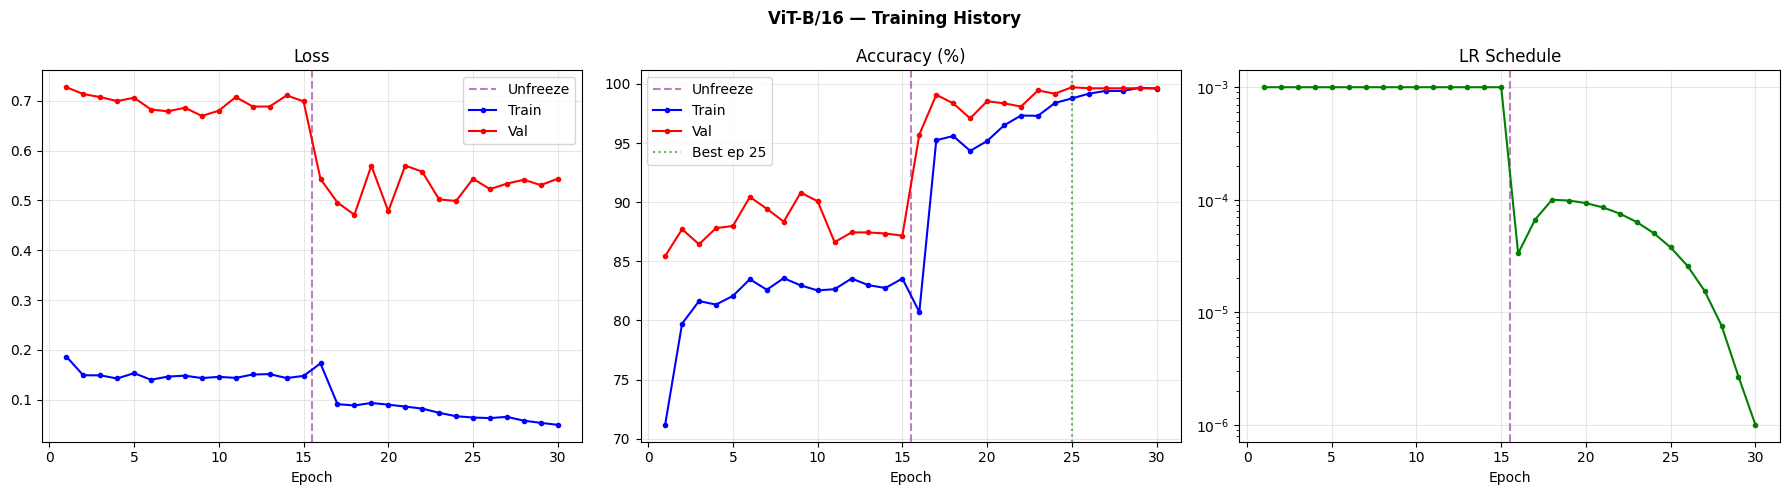

⏱️  ViT-B/16 total time: 00h 40m 18s


In [14]:
# ── Model 1: ViT-B/16 ────────────────────────────────────────────────
print("="*65)
print("  MODEL 1: ViT-B/16  (Vision Transformer — Dosovitskiy et al. 2020)")
print("  Architecture: Pure self-attention over patch tokens")
print("  Patch size: 16×16 → 14×14 = 196 tokens (+ 1 CLS) = 197 total")
print("  dmodel=768, 12 heads, 12 layers → ~86M params (B variant)")
print("="*65)

vit = timm.create_model(
    TRANSFORMER_MODELS['ViT-B/16'],
    pretrained=USE_PRETRAINED,
    num_classes=NUM_CLASSES,
    drop_rate=DROPOUT_RATE,
    attn_drop_rate=0.0,
    drop_path_rate=0.1
)
total_p = sum(p.numel() for p in vit.parameters())
print(f"Parameters: {total_p/1e6:.1f}M")
print(f"Head: {vit.head}")
img_size = getattr(vit.patch_embed, 'img_size', vit.default_cfg.get('input_size', 'N/A'))
patch_size = getattr(vit.patch_embed, 'patch_size', 'N/A')
print(f"Input size: {img_size}  Patch: {patch_size}")

t_start = time.time()
vit, hist_vit, best_vit = train_transformer(vit, 'ViT-B/16')
elapsed = time.time() - t_start
plot_history(hist_vit, 'ViT-B/16')
print(f"⏱️  ViT-B/16 total time: {int(elapsed//3600):02d}h {int((elapsed%3600)//60):02d}m {int(elapsed%60):02d}s")

  MODEL 2: Swin-Tiny  (Swin Transformer — Liu et al. 2021)
  Architecture: Hierarchical ViT with SHIFTED WINDOWS
  Key ideas:
    1. Window-based self-attention (local → efficient for high-res)
    2. Shifted windows let information flow across window boundaries
    3. Patch merging creates hierarchical feature maps (like CNNs)
    4. Swin-T: 4 stages, window=7×7, d=96→768


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Parameters: 27.5M
Head: ClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
  (drop): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=768, out_features=5, bias=True)
  (flatten): Identity()
)

 Training: Swin-Tiny  |  Total params: 27.5M
  Phase 1 (frozen): 15 epochs @ LR=1e-03  Trainable=0.0M
  Phase 2 (full)  : 15 epochs @ LR=1e-04  (+3 warmup epochs)
  Grad clip=1.0  WD=0.05  AMP=True
──────────────────────────────────────────────────────────────────────
  Ep | Ph |   TrLoss |   TrAcc |   VaLoss |   VaAcc |        LR
──────────────────────────────────────────────────────────────────────
   1 |  1 |   0.1969 |  69.16% |   0.8224 |  80.62% ⭐ | 1.00e-03  [59.8s]
   2 |  1 |   0.1575 |  79.11% |   0.7735 |  83.17% ⭐ | 1.00e-03  [60.2s]
   3 |  1 |   0.1522 |  81.47% |   0.7626 |  83.89% ⭐ | 1.00e-03  [59.9s]
   4 |  1 |   0.1515 |  82.76% |   0.7364 |  84.53% ⭐ | 1.00e-03  [59.1s]
   5 |  1 |   0.1449 |  82.31% |   0.7223 |  85.81% ⭐ | 1.00e

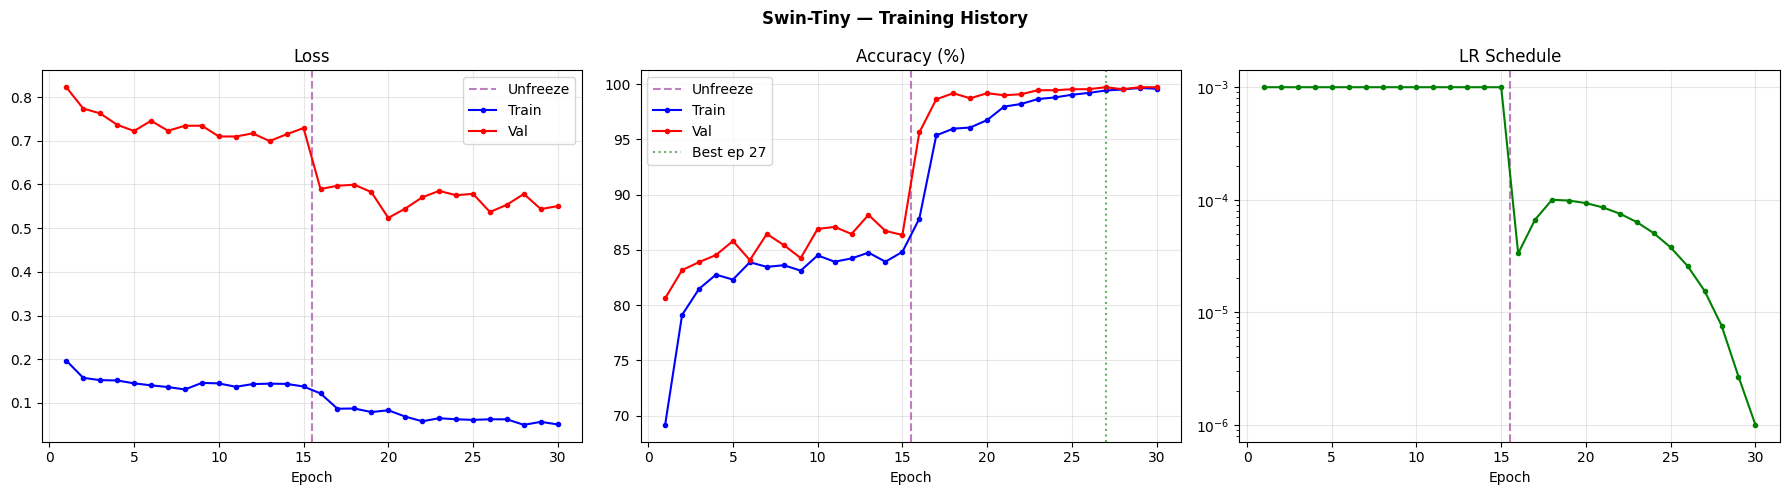

⏱️  Swin-Tiny total time: 00h 34m 10s


In [16]:
# ── Model 2: Swin-Tiny ───────────────────────────────────────────────
print("="*65)
print("  MODEL 2: Swin-Tiny  (Swin Transformer — Liu et al. 2021)")
print("  Architecture: Hierarchical ViT with SHIFTED WINDOWS")
print("  Key ideas:")
print("    1. Window-based self-attention (local → efficient for high-res)")
print("    2. Shifted windows let information flow across window boundaries")
print("    3. Patch merging creates hierarchical feature maps (like CNNs)")
print("    4. Swin-T: 4 stages, window=7×7, d=96→768")
print("="*65)

swin = timm.create_model(
    TRANSFORMER_MODELS['Swin-Tiny'],
    pretrained=USE_PRETRAINED,
    num_classes=NUM_CLASSES,
    drop_rate=DROPOUT_RATE,
    drop_path_rate=0.1
)
total_p = sum(p.numel() for p in swin.parameters())
print(f"Parameters: {total_p/1e6:.1f}M")
print(f"Head: {swin.head}")

t_start = time.time()
swin, hist_swin, best_swin = train_transformer(swin, 'Swin-Tiny')
elapsed = time.time() - t_start
plot_history(hist_swin, 'Swin-Tiny')
print(f"⏱️  Swin-Tiny total time: {int(elapsed//3600):02d}h {int((elapsed%3600)//60):02d}m {int(elapsed%60):02d}s")

  MODEL 3: DeiT-Small  (Data-efficient Image Transformer)
  Architecture: ViT + knowledge distillation token
  Key ideas:
    1. Same patch embedding as ViT-S (patch=16, d=384, 6 heads, 12 layers)
    2. Adds a DISTILLATION TOKEN alongside CLS token
    3. During training, distil token is supervised by a CNN teacher
    4. Achieves ViT-level accuracy with ∼3× less data (ImageNet only)
    5. At inference, average CLS + distil predictions


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Parameters: 21.7M

 Training: DeiT-Small  |  Total params: 21.7M
  Phase 1 (frozen): 15 epochs @ LR=1e-03  Trainable=0.0M
  Phase 2 (full)  : 15 epochs @ LR=1e-04  (+3 warmup epochs)
  Grad clip=1.0  WD=0.05  AMP=True
──────────────────────────────────────────────────────────────────────
  Ep | Ph |   TrLoss |   TrAcc |   VaLoss |   VaAcc |        LR
──────────────────────────────────────────────────────────────────────
   1 |  1 |   0.2119 |  65.98% |   0.8670 |  76.16% ⭐ | 1.00e-03  [54.8s]
   2 |  1 |   0.1757 |  76.11% |   0.8118 |  80.53% ⭐ | 1.00e-03  [54.6s]
   3 |  1 |   0.1667 |  77.79% |   0.7673 |  82.26% ⭐ | 1.00e-03  [54.7s]
   4 |  1 |   0.1686 |  77.90% |   0.7765 |  82.44% ⭐ | 1.00e-03  [55.2s]
   5 |  1 |   0.1542 |  78.87% |   0.7759 |  82.62% ⭐ | 1.00e-03  [55.7s]
   6 |  1 |   0.1567 |  79.40% |   0.7726 |  83.08% ⭐ | 1.00e-03  [55.1s]
   7 |  1 |   0.1558 |  79.58% |   0.7501 |  83.80% ⭐ | 1.00e-03  [54.6s]
   8 |  1 |   0.1636 |  79.89% |   0.7728 |  81.80% | 1.00

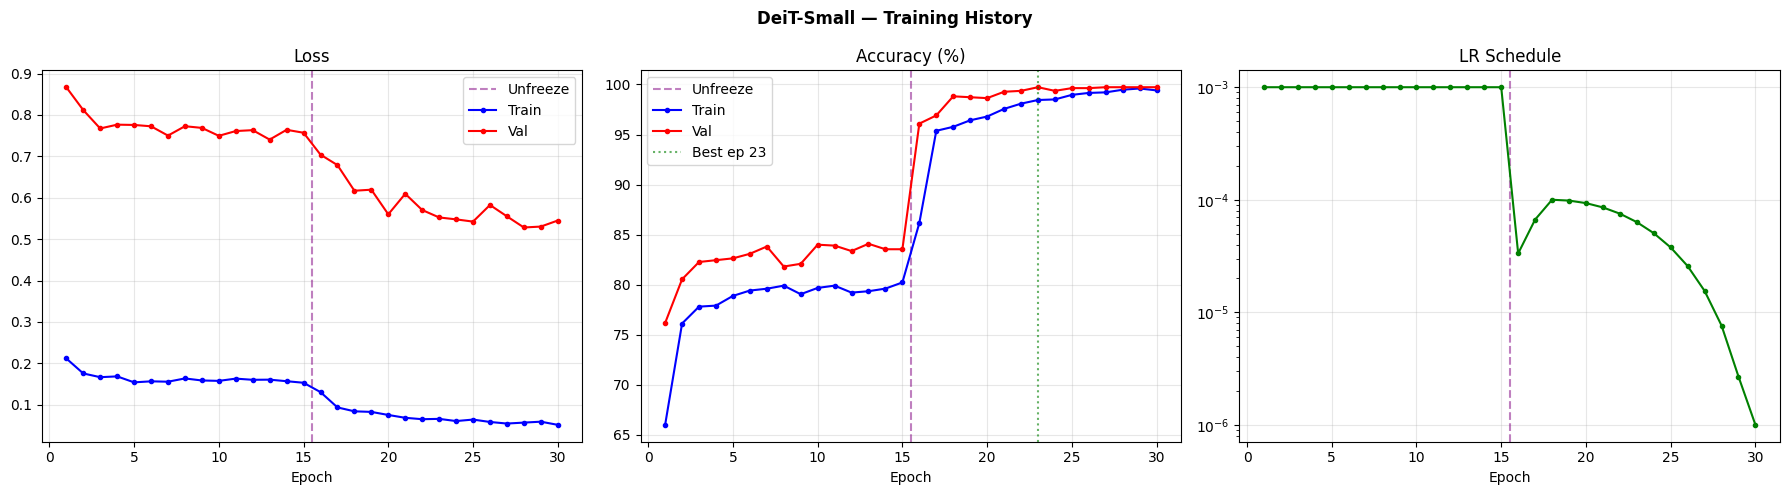

⏱️  DeiT-Small total time: 00h 28m 29s


In [17]:
# ── Model 3: DeiT-Small ──────────────────────────────────────────────
print("="*65)
print("  MODEL 3: DeiT-Small  (Data-efficient Image Transformer)")
print("  Architecture: ViT + knowledge distillation token")
print("  Key ideas:")
print("    1. Same patch embedding as ViT-S (patch=16, d=384, 6 heads, 12 layers)")
print("    2. Adds a DISTILLATION TOKEN alongside CLS token")
print("    3. During training, distil token is supervised by a CNN teacher")
print("    4. Achieves ViT-level accuracy with ∼3× less data (ImageNet only)")
print("    5. At inference, average CLS + distil predictions")
print("="*65)

deit = timm.create_model(
    TRANSFORMER_MODELS['DeiT-Small'],
    pretrained=USE_PRETRAINED,
    num_classes=NUM_CLASSES,
    drop_rate=DROPOUT_RATE,
    drop_path_rate=0.1
)
total_p = sum(p.numel() for p in deit.parameters())
print(f"Parameters: {total_p/1e6:.1f}M")

t_start = time.time()
deit, hist_deit, best_deit = train_transformer(deit, 'DeiT-Small')
elapsed = time.time() - t_start
plot_history(hist_deit, 'DeiT-Small')
print(f"⏱️  DeiT-Small total time: {int(elapsed//3600):02d}h {int((elapsed%3600)//60):02d}m {int(elapsed%60):02d}s")

## 📈 Evaluation & Comparison <a id='evaluation'></a>

In [18]:
# ── Evaluate all 3 models on test set ───────────────────────────────
ALL_MODELS = {
    'ViT-B/16'  : vit,
    'Swin-Tiny' : swin,
    'DeiT-Small': deit,
}
ALL_HISTORIES = {
    'ViT-B/16'  : hist_vit,
    'Swin-Tiny' : hist_swin,
    'DeiT-Small': hist_deit,
}

results = {}
crit_eval = nn.CrossEntropyLoss()

print(f"{'Model':<15} | {'Acc':>6} | {'F1(mac)':>8} | {'Prec':>6} | {'Rec':>6} | {'AUC':>6} | {'InfTime':>9}")
print('─'*67)
for name, model in ALL_MODELS.items():
    t_start = time.time()
    _, acc, preds, labels, probs = evaluate(model, test_loader, crit_eval)
    inf_ms = (time.time()-t_start) / len(test_dataset) * 1000
    lbin   = label_binarize(labels, classes=range(NUM_CLASSES))
    auc_s  = roc_auc_score(lbin, probs, multi_class='ovr', average='macro') * 100
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    results[name] = dict(accuracy=acc, f1=f1*100, precision=prec*100, recall=rec*100,
                          auc=auc_s, preds=preds, labels=labels, probs=probs, inf_time=inf_ms)
    print(f"{name:<15} | {acc:>5.2f}% | {f1*100:>7.2f}% | "
          f"{prec*100:>5.2f}% | {rec*100:>5.2f}% | {auc_s:>5.2f}% | {inf_ms:>7.3f}ms")

BEST_NAME = max(results, key=lambda k: results[k]['accuracy'])
print(f"\n🏆 Best Transformer: {BEST_NAME}  ({results[BEST_NAME]['accuracy']:.2f}%)")


Model           |    Acc |  F1(mac) |   Prec |    Rec |    AUC |   InfTime
───────────────────────────────────────────────────────────────────
ViT-B/16        | 99.82% |   99.82% | 99.82% | 99.81% | 100.00% |   6.833ms
Swin-Tiny       | 99.91% |   99.91% | 99.90% | 99.92% | 100.00% |   2.683ms
DeiT-Small      | 100.00% |  100.00% | 100.00% | 100.00% | 100.00% |   2.371ms

🏆 Best Transformer: DeiT-Small  (100.00%)


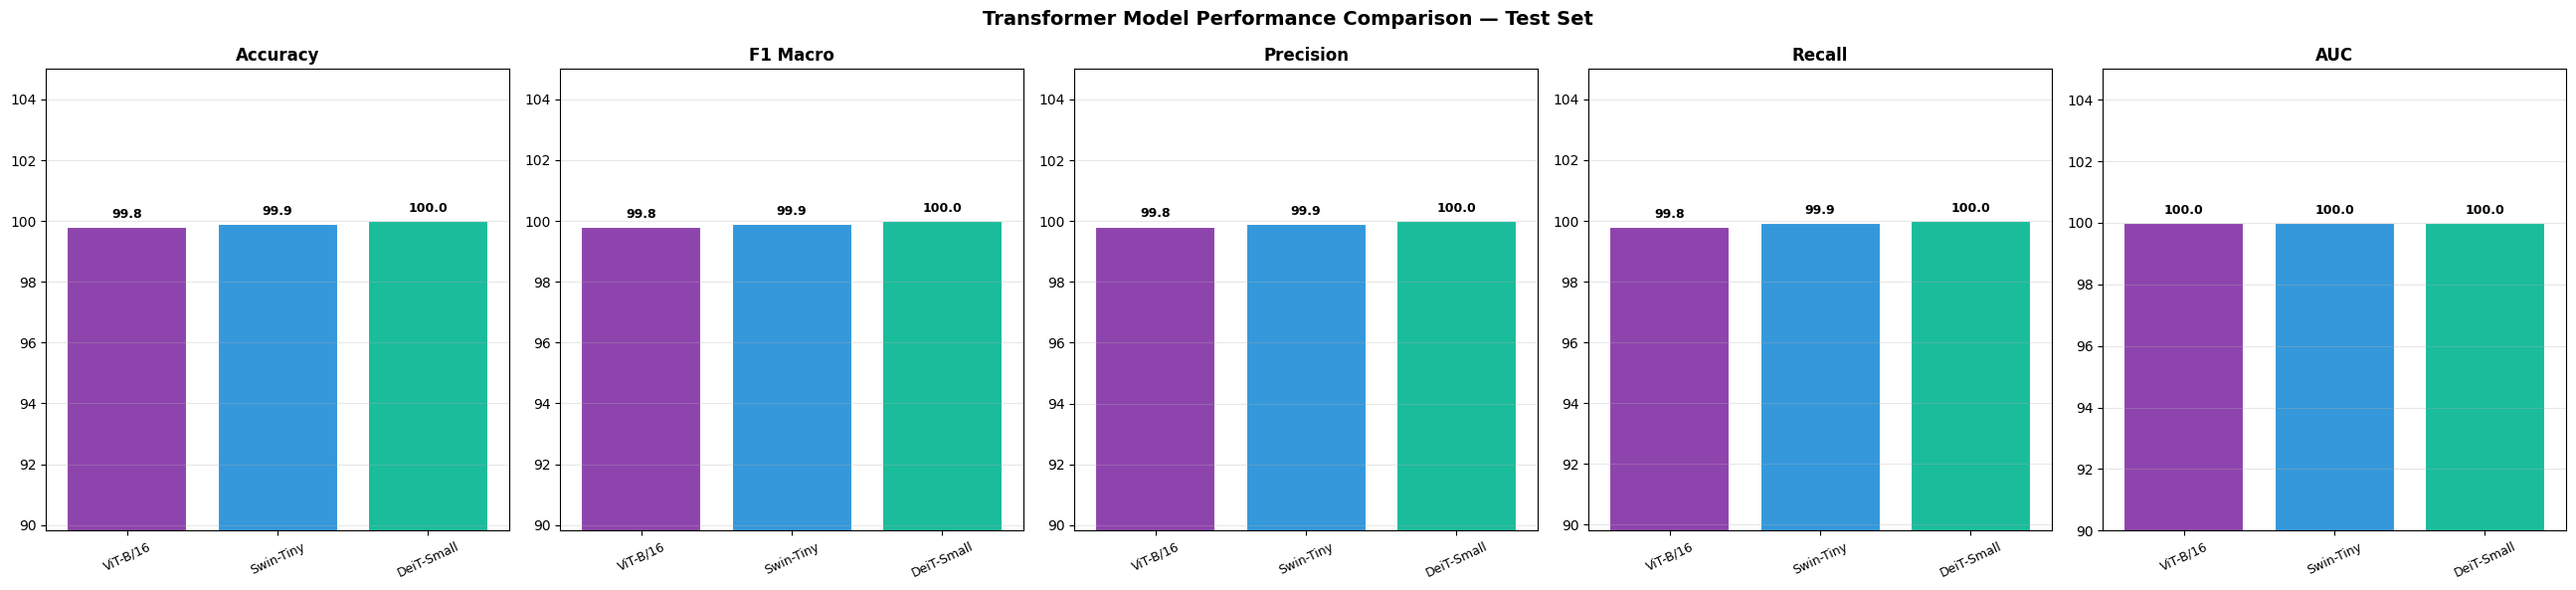

In [19]:
# ── Comparison bar charts ────────────────────────────────────────────
names    = list(results.keys())
metrics  = ['accuracy','f1','precision','recall','auc']
m_labels = ['Accuracy','F1 Macro','Precision','Recall','AUC']
tcolors  = ['#8E44AD','#3498DB','#1ABC9C']

fig, axes = plt.subplots(1, 5, figsize=(26, 6))
fig.suptitle('Transformer Model Performance Comparison — Test Set', fontsize=14, fontweight='bold')
for ax, metric, mlbl in zip(axes, metrics, m_labels):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=tcolors, edgecolor='white', linewidth=1.5)
    ax.set_title(mlbl, fontweight='bold')
    ax.set_ylim(max(0, min(vals)-10), 105)
    ax.tick_params(axis='x', rotation=25, labelsize=9)
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_comparison_tf.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()


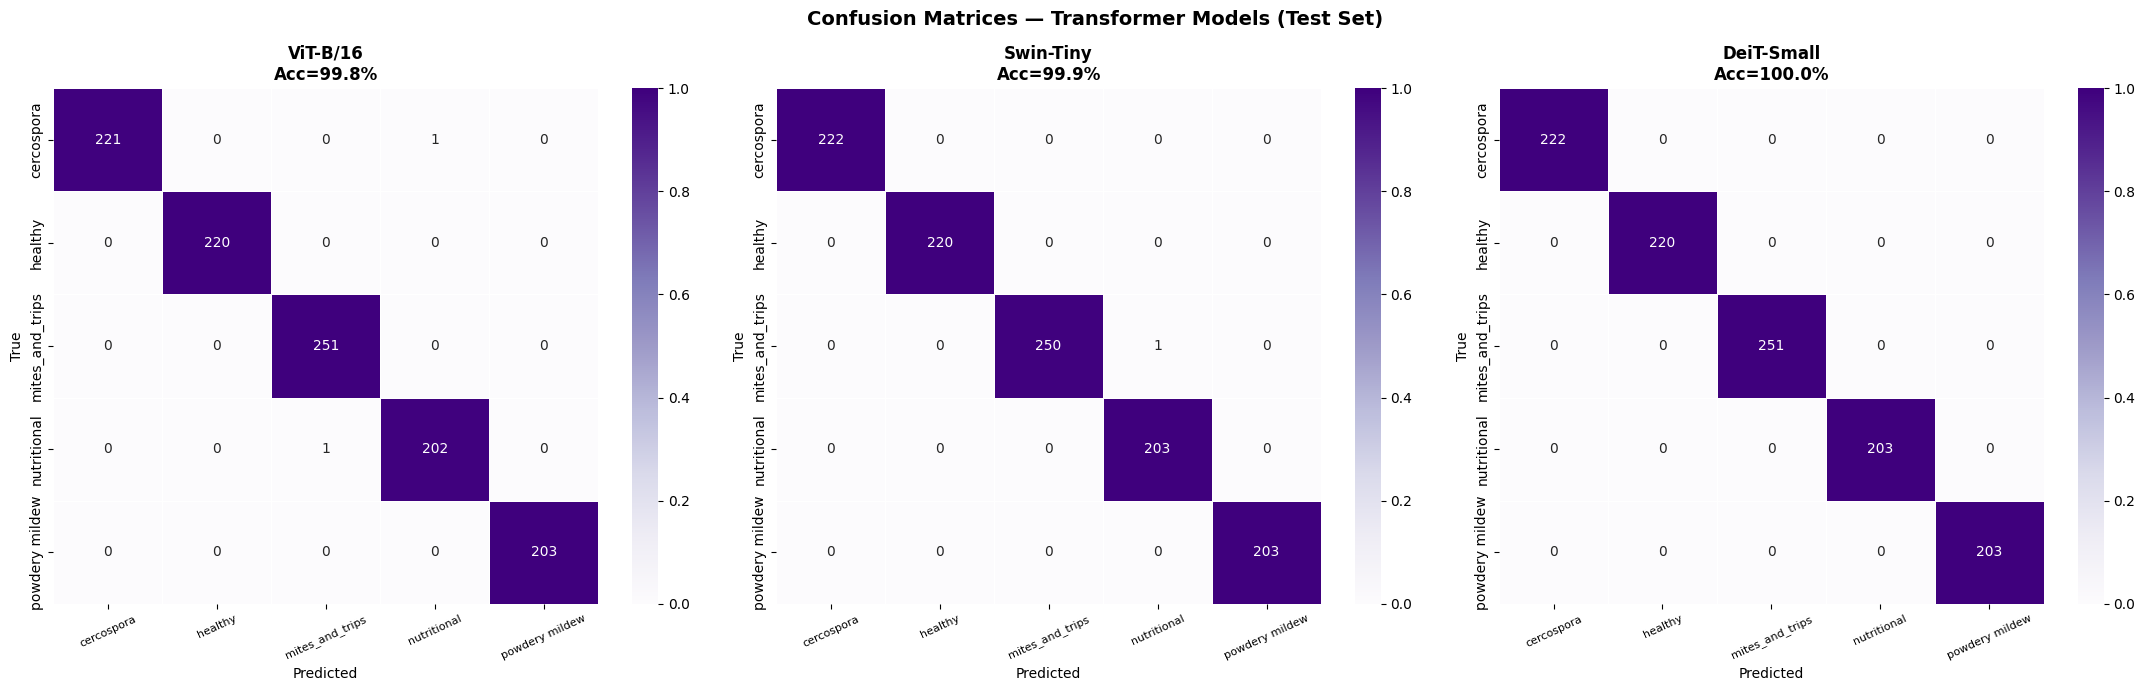

In [21]:
# ── Confusion matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Confusion Matrices — Transformer Models (Test Set)', fontsize=14, fontweight='bold')
for ax, name in zip(axes, names):
    cm  = confusion_matrix(results[name]['labels'], results[name]['preds'])
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cmn, annot=cm, fmt='d', ax=ax, cmap='Purples', vmin=0, vmax=1,
                xticklabels=short, yticklabels=short, cbar=True, linewidths=0.5)
    ax.set_title(f'{name}\nAcc={results[name]["accuracy"]:.1f}%', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=25, labelsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrices_tf.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()


Classification Report — DeiT-Small (Test Set)
                 precision    recall  f1-score   support

     cercospora     1.0000    1.0000    1.0000       222
        healthy     1.0000    1.0000    1.0000       220
mites_and_trips     1.0000    1.0000    1.0000       251
    nutritional     1.0000    1.0000    1.0000       203
 powdery mildew     1.0000    1.0000    1.0000       203

       accuracy                         1.0000      1099
      macro avg     1.0000    1.0000    1.0000      1099
   weighted avg     1.0000    1.0000    1.0000      1099



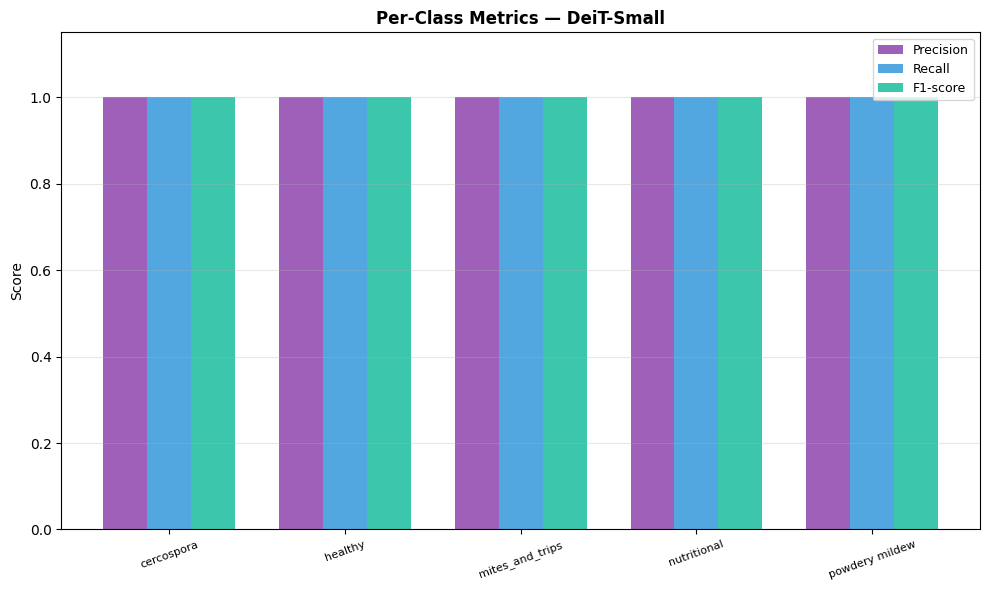

In [22]:
# ── Classification report + per-class bar ───────────────────────────
br = results[BEST_NAME]
print(f"\n{'='*65}\nClassification Report — {BEST_NAME} (Test Set)\n{'='*65}")
print(classification_report(br['labels'], br['preds'], target_names=CLASS_NAMES, digits=4))

rep = classification_report(br['labels'], br['preds'],
                              target_names=CLASS_NAMES, output_dict=True)
fig, ax = plt.subplots(figsize=(max(10, NUM_CLASSES*2), 6))
x, w = np.arange(NUM_CLASSES), 0.25
ax.bar(x-w, [rep[c]['precision'] for c in CLASS_NAMES], w, label='Precision', color='#8E44AD', alpha=0.85)
ax.bar(x,   [rep[c]['recall']    for c in CLASS_NAMES], w, label='Recall',    color='#3498DB', alpha=0.85)
ax.bar(x+w, [rep[c]['f1-score']  for c in CLASS_NAMES], w, label='F1-score',  color='#1ABC9C', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(short, rotation=20, fontsize=8)
ax.set_ylim(0, 1.15); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.set_title(f'Per-Class Metrics — {BEST_NAME}', fontweight='bold'); ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/per_class_metrics_tf.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()


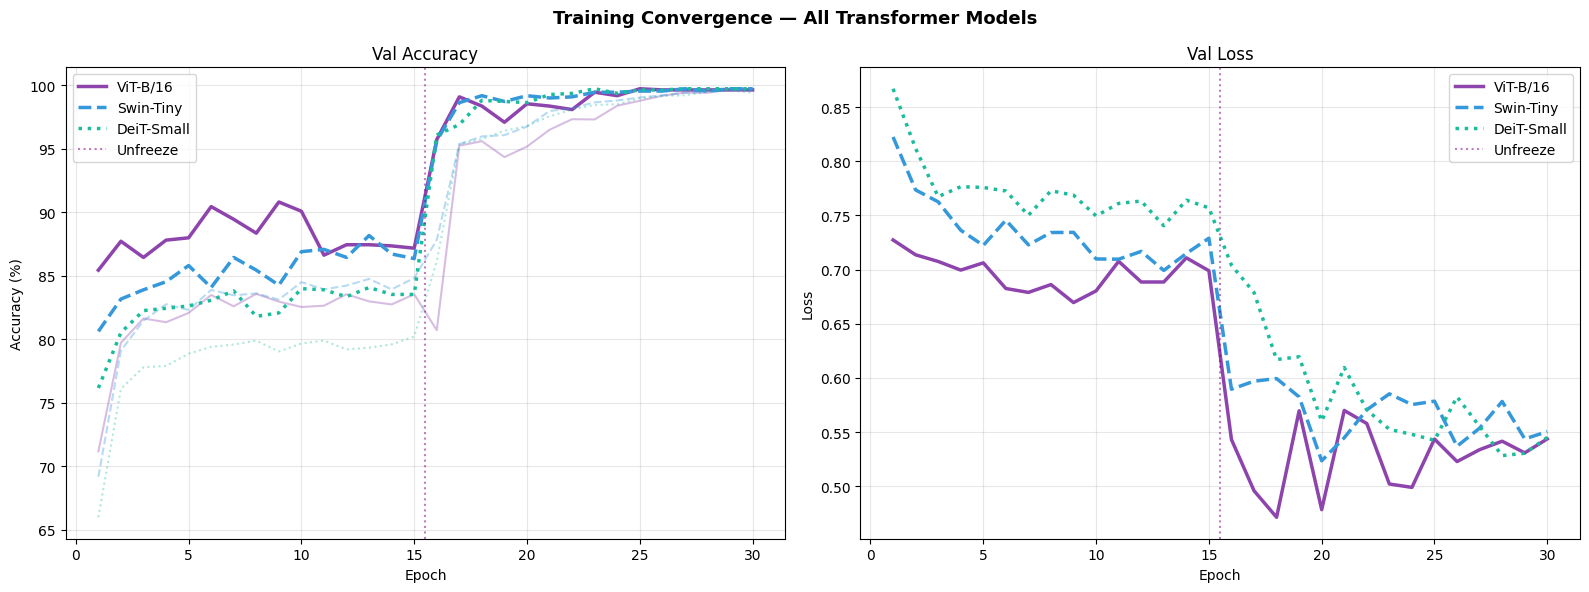

In [23]:
# ── Convergence comparison ───────────────────────────────────────────
fig, (a1, a2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training Convergence — All Transformer Models', fontsize=13, fontweight='bold')
styles  = ['-', '--', ':']
pcolors = ['#8E44AD', '#3498DB', '#1ABC9C']
for (name, h), ls, pc in zip(ALL_HISTORIES.items(), styles, pcolors):
    ep = range(1, len(h['val_acc'])+1)
    a1.plot(ep, h['train_acc'], ls=ls, color=pc, alpha=0.35, lw=1.5)
    a1.plot(ep, h['val_acc'],   ls=ls, color=pc, lw=2.5, label=name)
    a2.plot(ep, h['val_loss'],  ls=ls, color=pc, lw=2.5, label=name)
if FREEZE_EPOCHS > 0:
    a1.axvline(FREEZE_EPOCHS+0.5, color='purple', ls=':', alpha=0.5, label='Unfreeze')
    a2.axvline(FREEZE_EPOCHS+0.5, color='purple', ls=':', alpha=0.5, label='Unfreeze')
a1.set_title('Val Accuracy'); a1.set_xlabel('Epoch'); a1.set_ylabel('Accuracy (%)'); a1.legend(); a1.grid(alpha=0.3)
a2.set_title('Val Loss');     a2.set_xlabel('Epoch'); a2.set_ylabel('Loss');         a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/convergence_tf.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()


Generating ViT attention maps for 5 test samples...


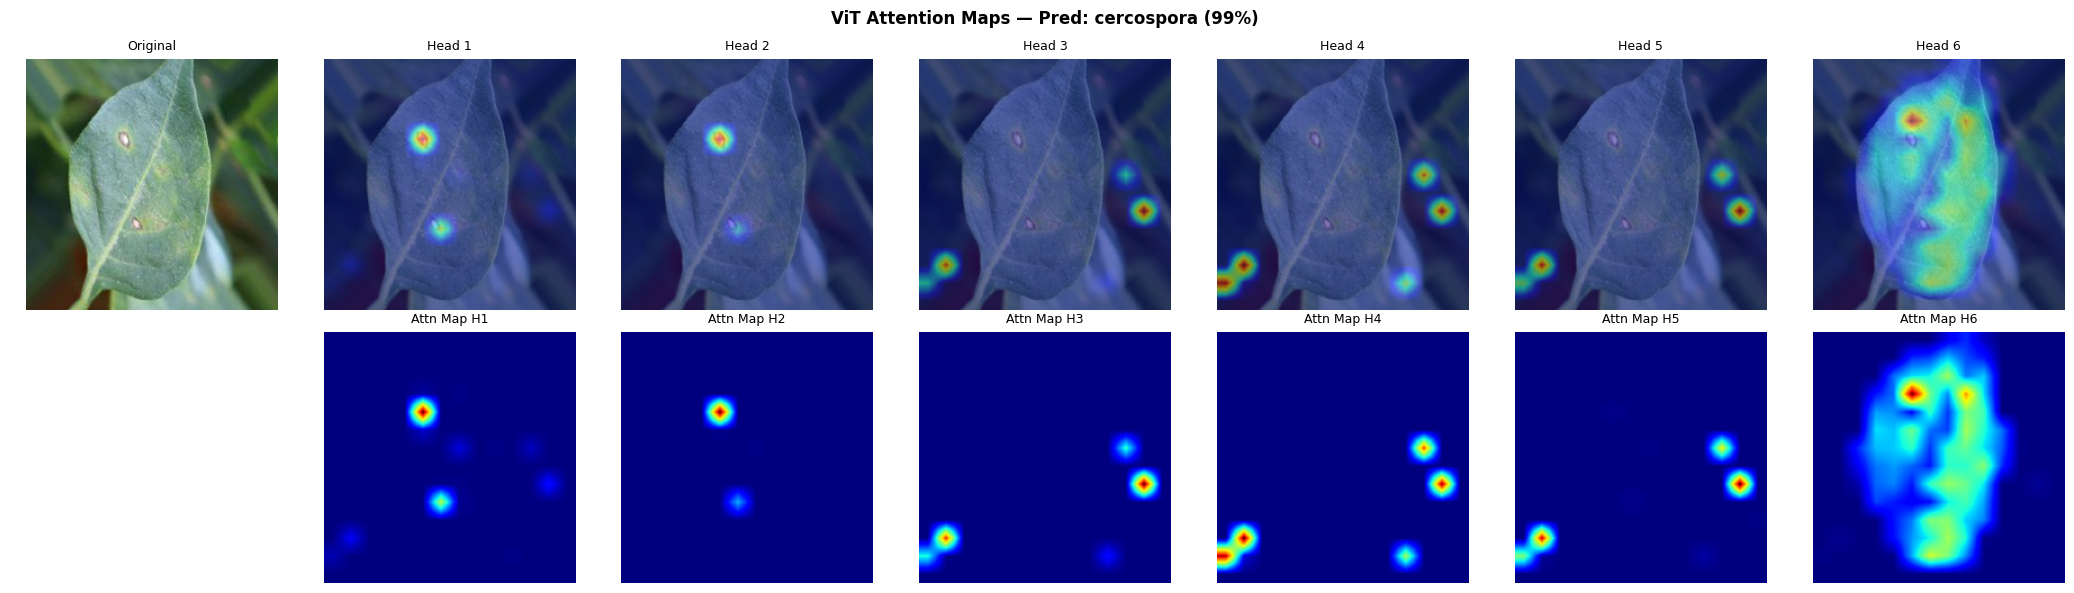

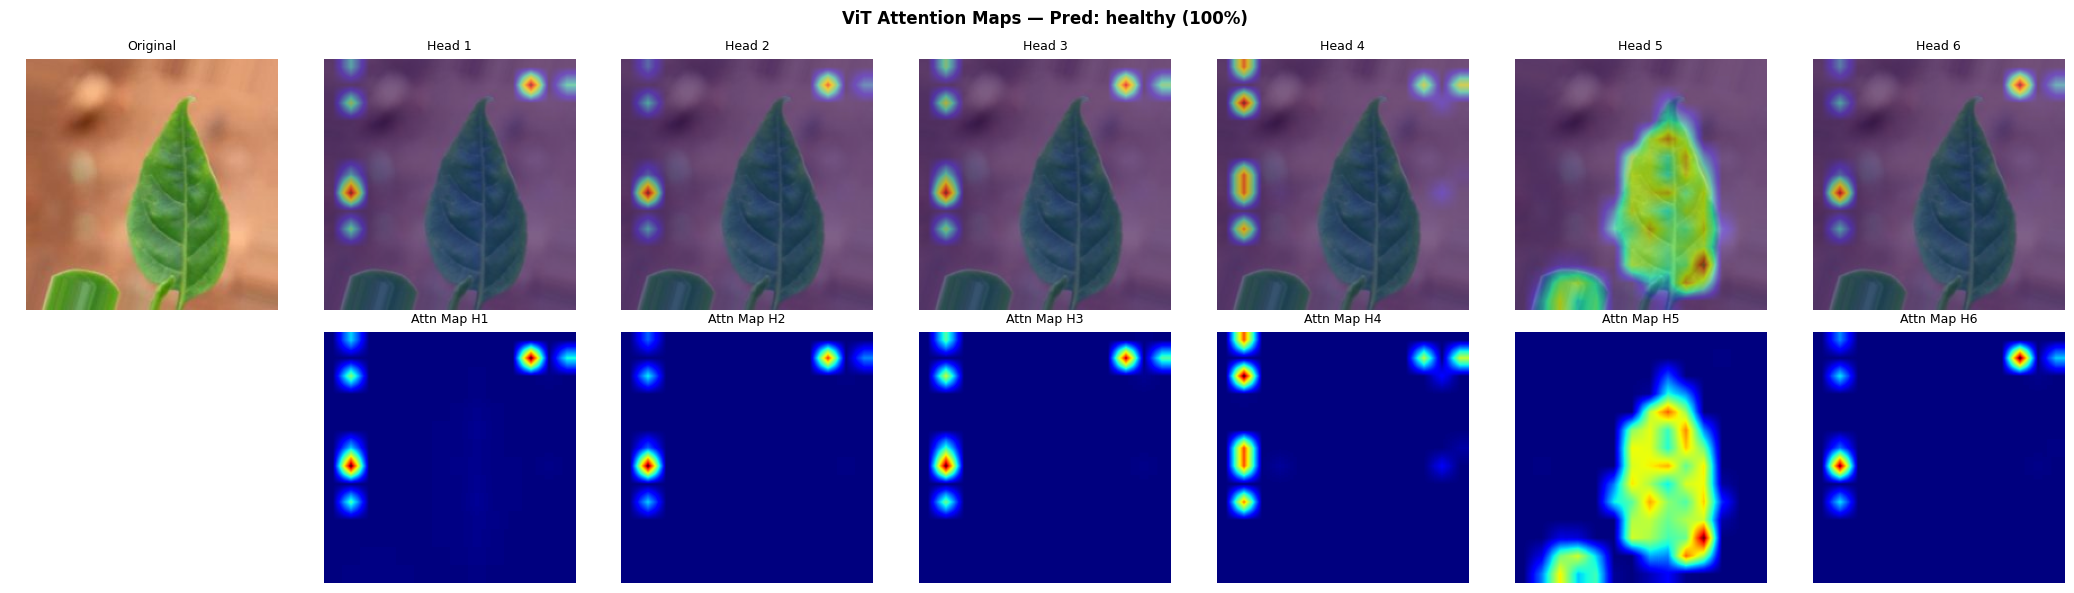

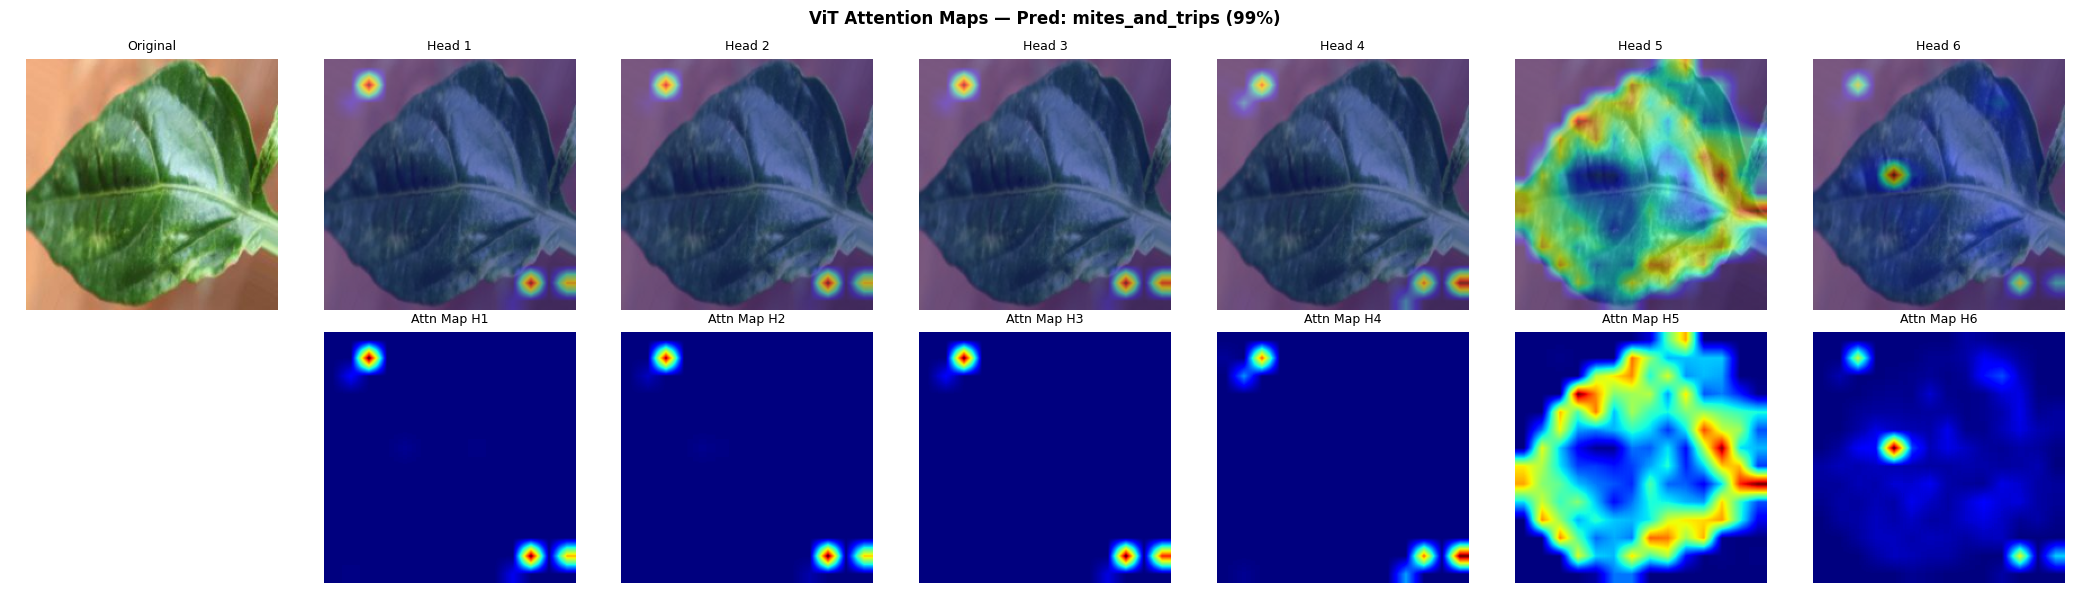

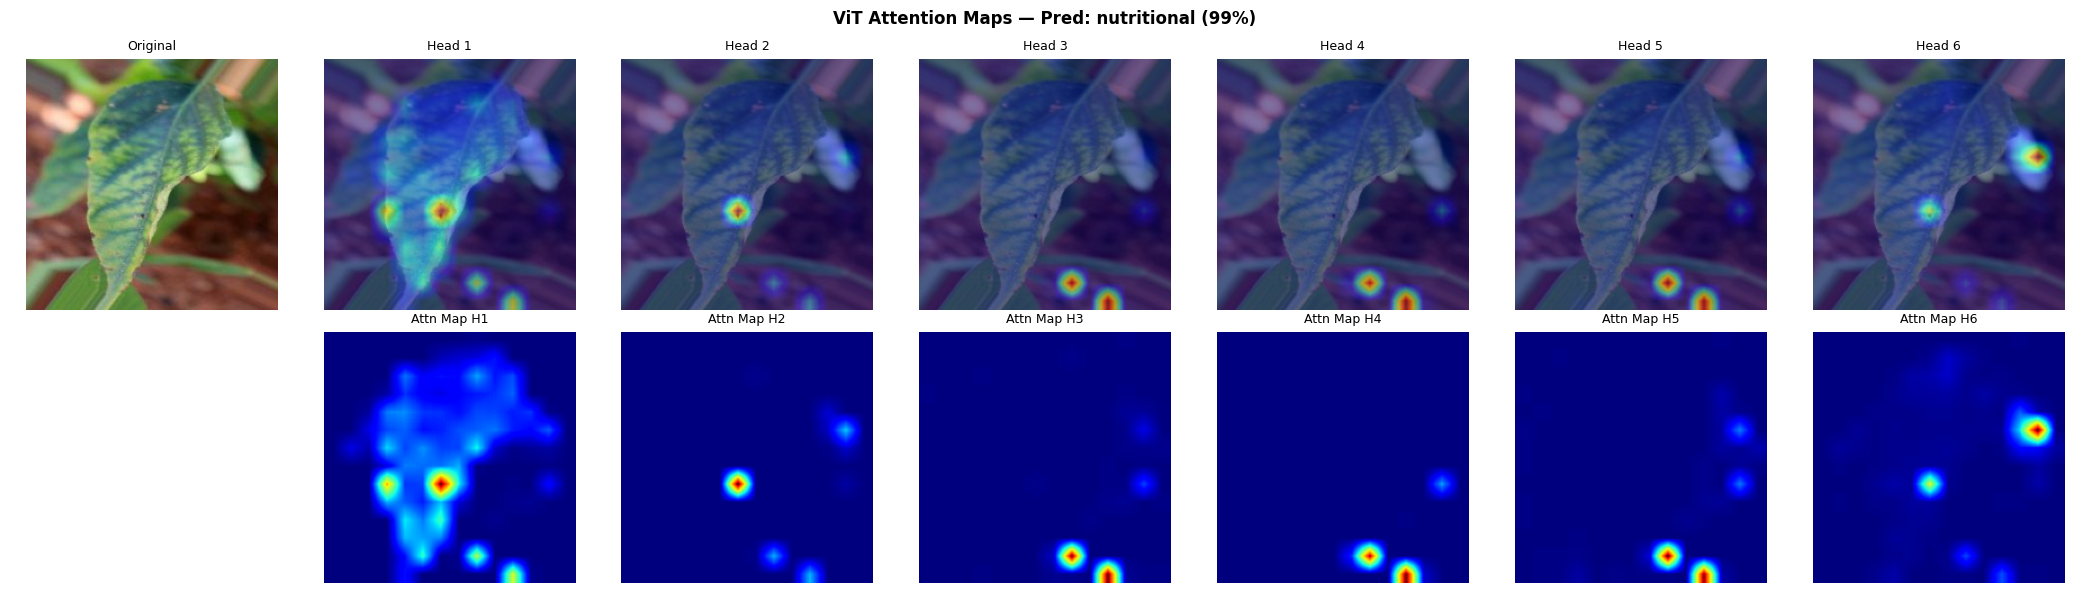

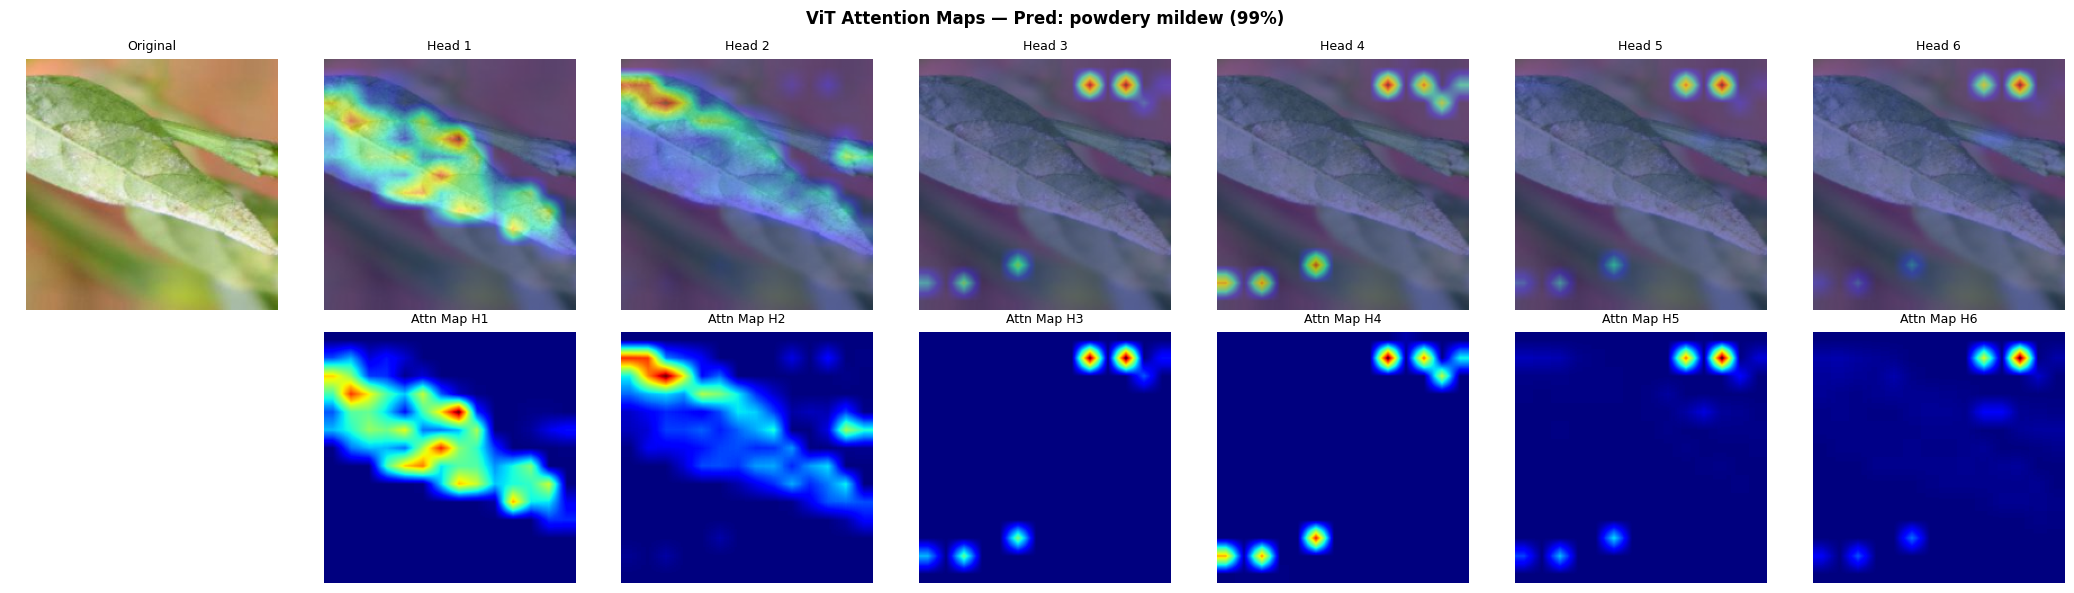

In [24]:
# ── Attention map visualisation (ViT) ───────────────────────────────
"""
For ViT: extract last-layer attention weights for the [CLS] token.
The attention from CLS → patch_i tells us how much the model focuses on patch i.
We reshape from (num_patches,) to (H_patches, W_patches) and overlay on the image.
"""

def visualise_vit_attention(model, img_path, n_heads_show=6):
    """Visualise multi-head attention maps from the last ViT block."""
    model.eval()
    img  = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    raw  = np.array(img) / 255.0
    inp  = val_transform(img).unsqueeze(0).to(DEVICE)

    attn_maps = []

    def hook_fn(module, input, output):
        # output = (B, seq_len, embed_dim) — NOT the attn weights
        # Recompute attention weights from the module's input instead
        with torch.no_grad():
            B, N, C = input[0].shape
            qkv = module.qkv(input[0])
            qkv = qkv.reshape(B, N, 3, module.num_heads, C // module.num_heads)
            qkv = qkv.permute(2, 0, 3, 1, 4)           # (3, B, heads, seq, head_dim)
            q, k, v = qkv.unbind(0)                     # each: (B, heads, seq, head_dim)
            scale = module.scale
            attn_w = (q @ k.transpose(-2, -1)) * scale  # (B, heads, seq, seq)
            attn_w = attn_w.softmax(dim=-1)
            attn_maps.append(attn_w.detach().cpu())

    handle = None
    try:
        last_block = model.blocks[-1]
        handle = last_block.attn.register_forward_hook(hook_fn)
    except AttributeError:
        print("Cannot extract attention (non-ViT model); skipping.")
        return None

    with torch.no_grad():
        out = model(inp)
    if handle:
        handle.remove()

    if not attn_maps:
        return None

    attn      = attn_maps[0][0]          # (num_heads, seq, seq)
    num_heads = attn.shape[0]
    cls_attn  = attn[:, 0, 1:]           # (num_heads, n_patches) — CLS → patches
    n_patch   = int(cls_attn.shape[1] ** 0.5)

    pred = out.float().argmax(1).item()
    conf = F.softmax(out.float(), dim=1)[0, pred].item()

    fig, axes = plt.subplots(2, min(n_heads_show, num_heads) + 1,
                              figsize=((min(n_heads_show, num_heads) + 1) * 3, 6))
    fig.suptitle(f'ViT Attention Maps — Pred: {CLASS_NAMES[pred][:15]} ({conf:.0%})',
                 fontweight='bold')

    axes[0, 0].imshow(raw); axes[0, 0].set_title('Original', fontsize=9); axes[0, 0].axis('off')
    axes[1, 0].axis('off')

    for hi in range(min(n_heads_show, num_heads)):
        hmap = cls_attn[hi].reshape(n_patch, n_patch).numpy()
        hmap = (hmap - hmap.min()) / (hmap.max() - hmap.min() + 1e-8)
        from PIL import Image as PIL_Image
        hmap_resized = np.array(
            PIL_Image.fromarray((hmap * 255).astype(np.uint8))
            .resize((IMG_SIZE, IMG_SIZE), PIL_Image.BILINEAR)
        ) / 255.0
        axes[0, hi+1].imshow(raw)
        axes[0, hi+1].imshow(hmap_resized, alpha=0.5, cmap='jet')
        axes[0, hi+1].set_title(f'Head {hi+1}', fontsize=9); axes[0, hi+1].axis('off')
        axes[1, hi+1].imshow(hmap_resized, cmap='jet')
        axes[1, hi+1].set_title(f'Attn Map H{hi+1}', fontsize=9); axes[1, hi+1].axis('off')

    plt.tight_layout()
    return fig

# Show attention maps for 5 test samples using ViT
print("Generating ViT attention maps for 5 test samples...")
sample_test_paths = []
for ci in range(NUM_CLASSES):
    idxs = [i for i, l in enumerate(test_labels) if l == ci]
    if idxs: sample_test_paths.append(test_paths[random.choice(idxs)])
    if len(sample_test_paths) >= 5: break

for i, p in enumerate(sample_test_paths[:5]):
    fig = visualise_vit_attention(vit, p, n_heads_show=6)
    if fig:
        plt.savefig(f'{OUTPUT_DIR}/vit_attention_{i}.png', dpi=FIGDPI, bbox_inches='tight')
        plt.show()

## 🛡️ Robustness Analysis <a id='robustness'></a>

In [25]:
# ── Corruption transforms ────────────────────────────────────────────
def make_noise_transform(sigma):
    return transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.Lambda(lambda x: x + torch.randn_like(x)*sigma)])

def make_blur_transform(k):
    k = k if k%2==1 else k+1
    return transforms.Compose([
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.GaussianBlur(kernel_size=k, sigma=k/3),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

CORRUPTIONS = {'✅ Clean': val_transform}
for s in NOISE_LEVELS:  CORRUPTIONS[f'GaussNoise σ={s}'] = make_noise_transform(s)
for k in BLUR_KERNELS:  CORRUPTIONS[f'GaussBlur k={k}']  = make_blur_transform(k)
CORRUPTIONS['Overexposure'] = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.ColorJitter(brightness=(1.8,1.8)),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
CORRUPTIONS['Low Contrast'] = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.ColorJitter(contrast=(0.3,0.3)),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

# Resolution sensitivity test (transformer-specific)
for res in [112, 160, 256, 320]:
    CORRUPTIONS[f'Res={res}'] = transforms.Compose([
        transforms.Resize((res, res)),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),   # re-interpolate to model input
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

rob_all = {}
for mname, model in ALL_MODELS.items():
    print(f"\n⏳ Robustness: {mname}")
    rob_all[mname] = {}
    for cname, ctf in CORRUPTIONS.items():
        c_ds = PathDataset(test_paths, test_labels, transform=ctf)
        c_ld = DataLoader(c_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        _, acc, preds, lbls, _ = evaluate(model, c_ld)
        rob_all[mname][cname] = {'accuracy': acc, 'f1': f1_score(lbls, preds, average='macro')*100}
        print(f"  {cname:<25}  Acc={acc:.2f}%")



⏳ Robustness: ViT-B/16
  ✅ Clean                    Acc=99.82%
  GaussNoise σ=0.05          Acc=99.82%
  GaussNoise σ=0.15          Acc=99.82%
  GaussBlur k=3              Acc=99.82%
  GaussBlur k=9              Acc=95.72%
  Overexposure               Acc=98.36%
  Low Contrast               Acc=99.82%
  Res=112                    Acc=99.36%
  Res=160                    Acc=99.91%
  Res=256                    Acc=99.82%
  Res=320                    Acc=99.91%

⏳ Robustness: Swin-Tiny
  ✅ Clean                    Acc=99.91%
  GaussNoise σ=0.05          Acc=99.64%
  GaussNoise σ=0.15          Acc=99.27%
  GaussBlur k=3              Acc=99.00%
  GaussBlur k=9              Acc=85.17%
  Overexposure               Acc=97.82%
  Low Contrast               Acc=99.82%
  Res=112                    Acc=96.18%
  Res=160                    Acc=99.27%
  Res=256                    Acc=99.91%
  Res=320                    Acc=99.91%

⏳ Robustness: DeiT-Small
  ✅ Clean                    Acc=100.00%
  Ga

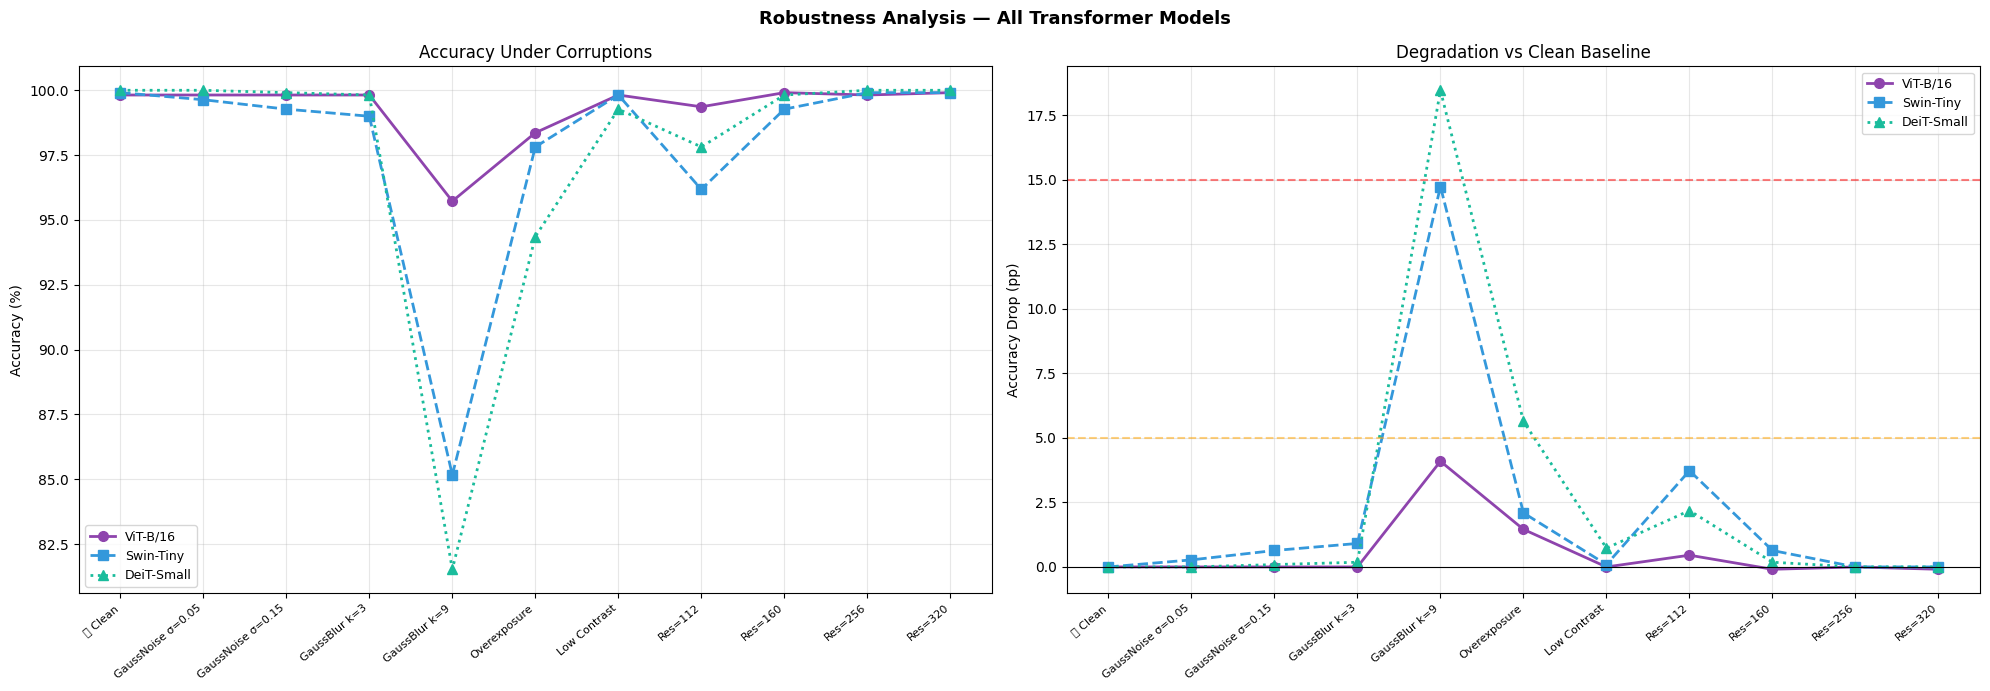


Robustness summary:
  ViT-B/16        Clean:99.8%  WorstCorr:95.7%  WorstRes:99.4%
  Swin-Tiny       Clean:99.9%  WorstCorr:85.2%  WorstRes:96.2%
  DeiT-Small      Clean:100.0%  WorstCorr:81.5%  WorstRes:97.8%


In [37]:
# ── Robustness plots ─────────────────────────────────────────────────
cnames  = list(CORRUPTIONS.keys())
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Robustness Analysis — All Transformer Models', fontsize=13, fontweight='bold')

for (mname, rob), ls, pc in zip(rob_all.items(), ['-o','--s',':^'], tcolors):
    accs  = [rob[c]['accuracy'] for c in cnames]
    drops = [rob['✅ Clean']['accuracy'] - a for a in accs]
    axes[0].plot(range(len(cnames)), accs,  ls, color=pc, lw=2, ms=7, label=mname)
    axes[1].plot(range(len(cnames)), drops, ls, color=pc, lw=2, ms=7, label=mname)

for ax in axes:
    ax.set_xticks(range(len(cnames)))
    ax.set_xticklabels(cnames, rotation=40, ha='right', fontsize=8)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_title('Accuracy Under Corruptions')
axes[1].set_ylabel('Accuracy Drop (pp)'); axes[1].set_title('Degradation vs Clean Baseline')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].axhline(5,  color='orange', ls='--', alpha=0.5, label='5pp')
axes[1].axhline(15, color='red',    ls='--', alpha=0.5, label='15pp')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/robustness_tf.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()

print("\nRobustness summary:")
for mname, rob in rob_all.items():
    clean = rob['✅ Clean']['accuracy']
    # Separate standard corruptions from resolution tests
    std_c = {k:v for k,v in rob.items() if 'Res=' not in k}
    res_c = {k:v for k,v in rob.items() if 'Res=' in k}
    worst_std = min(v['accuracy'] for v in std_c.values())
    worst_res = min(v['accuracy'] for v in res_c.values()) if res_c else clean
    print(f"  {mname:<15} Clean:{clean:.1f}%  WorstCorr:{worst_std:.1f}%  WorstRes:{worst_res:.1f}%")


## 🔍 Error Analysis with Attention Maps <a id='error'></a>

BEST_NAME     : DeiT-Small
Total samples : 1099
Correct       : 1099
Accuracy      : 100.00%
Unique preds  : [0 1 2 3 4]
Unique labels : [0 1 2 3 4]


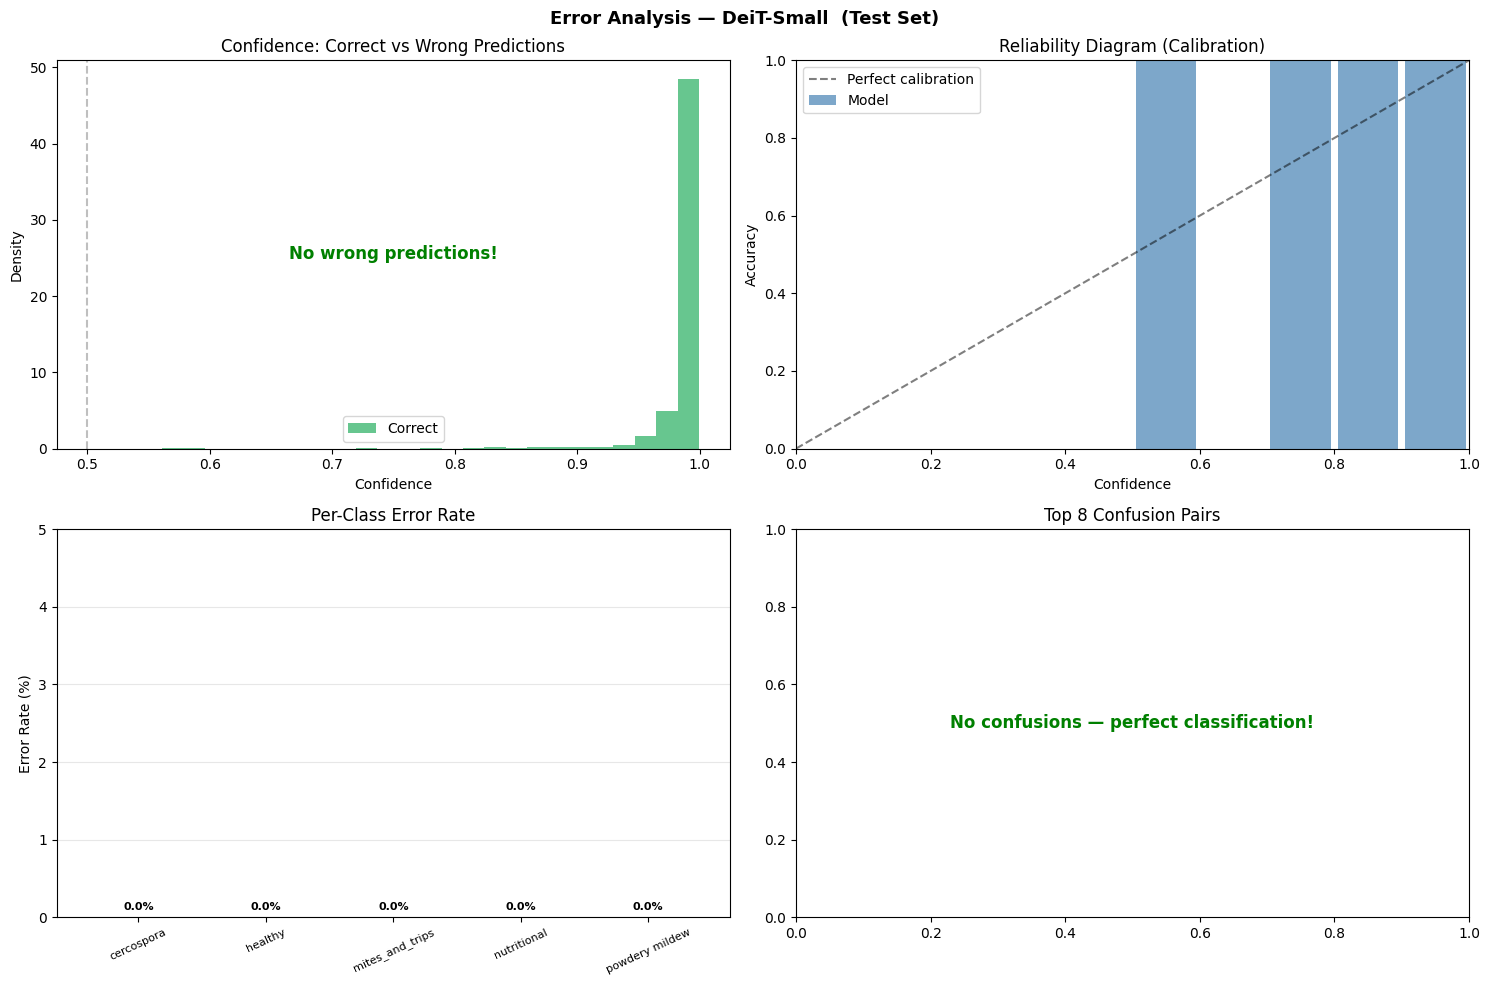

In [39]:
# ── Debug check first ─────────────────────────────────────────────────
preds_   = results[BEST_NAME]['preds']
labels_  = results[BEST_NAME]['labels']
probs_   = results[BEST_NAME]['probs']

print(f"BEST_NAME     : {BEST_NAME}")
print(f"Total samples : {len(labels_)}")
print(f"Correct       : {(preds_ == labels_).sum()}")
print(f"Accuracy      : {(preds_ == labels_).mean()*100:.2f}%")
print(f"Unique preds  : {np.unique(preds_)}")
print(f"Unique labels : {np.unique(labels_)}")

# ── Confidence distribution & calibration ────────────────────────────
maxp    = probs_.max(axis=1)
correct = (preds_ == labels_)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Error Analysis — {BEST_NAME}  (Test Set)', fontsize=13, fontweight='bold')

# ── Plot 1: Confidence histograms ─────────────────────────────────────
if correct.sum() > 0:
    axes[0,0].hist(maxp[correct], bins=25, alpha=0.7,
                   color='#27AE60', label='Correct', density=True)
if (~correct).sum() > 0:
    axes[0,0].hist(maxp[~correct], bins=25, alpha=0.7,
                   color='#E74C3C', label='Wrong', density=True)
else:
    axes[0,0].text(0.5, 0.5, 'No wrong predictions!',
                   ha='center', va='center',
                   transform=axes[0,0].transAxes,
                   fontsize=12, color='green', fontweight='bold')
axes[0,0].set_xlabel('Confidence')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Confidence: Correct vs Wrong Predictions')
axes[0,0].legend()
axes[0,0].axvline(0.5, color='gray', ls='--', alpha=0.5)

# ── Plot 2: Reliability diagram (calibration) ─────────────────────────
bins    = np.linspace(0, 1, 11)
bc      = (bins[:-1] + bins[1:]) / 2
cal_acc = []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (maxp >= lo) & (maxp < hi)
    cal_acc.append(correct[m].mean() if m.sum() > 0 else np.nan)

axes[0,1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
axes[0,1].bar(bc, np.nan_to_num(cal_acc), width=0.09,
              alpha=0.7, color='steelblue', label='Model')
axes[0,1].set_title('Reliability Diagram (Calibration)')
axes[0,1].set_xlabel('Confidence')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].set_xlim(0, 1)
axes[0,1].set_ylim(0, 1)

# ── Plot 3: Per-class error rate ──────────────────────────────────────
cls_errs = [
    1 - correct[labels_ == i].mean() if (labels_ == i).sum() > 0 else 0
    for i in range(NUM_CLASSES)
]
bars = axes[1,0].bar(
    short,
    [e * 100 for e in cls_errs],
    color=[COLORS[i % len(COLORS)] for i in range(NUM_CLASSES)]
)
axes[1,0].set_ylabel('Error Rate (%)')
axes[1,0].set_title('Per-Class Error Rate')
axes[1,0].set_ylim(0, max(max(e * 100 for e in cls_errs) + 5, 5))
axes[1,0].tick_params(axis='x', rotation=25, labelsize=8)
axes[1,0].grid(axis='y', alpha=0.3)
for b, e in zip(bars, cls_errs):
    axes[1,0].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.1,
        f'{e * 100:.1f}%',
        ha='center', fontsize=8, fontweight='bold'
    )

# ── Plot 4: Top confusion pairs ───────────────────────────────────────
cm    = confusion_matrix(labels_, preds_)
pairs = [
    (f'{CLASS_NAMES[i][:10]} → {CLASS_NAMES[j][:10]}', cm[i, j])
    for i in range(NUM_CLASSES)
    for j in range(NUM_CLASSES)
    if i != j and cm[i, j] > 0
]
pairs.sort(key=lambda x: -x[1])

if pairs:
    pair_names, pair_counts = zip(*pairs[:8])
    axes[1,1].barh(pair_names, pair_counts, color='#E74C3C', alpha=0.8)
    axes[1,1].set_xlabel('Count')
    axes[1,1].set_title('Top 8 Confusion Pairs')
    axes[1,1].grid(axis='x', alpha=0.3)
else:
    axes[1,1].text(0.5, 0.5, 'No confusions — perfect classification!',
                   ha='center', va='center',
                   transform=axes[1,1].transAxes,
                   fontsize=12, color='green', fontweight='bold')
    axes[1,1].set_title('Top 8 Confusion Pairs')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/error_analysis_cnn.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()

Generating attention maps for misclassified ViT samples...
Found 2 misclassified samples (conf>50%) to visualise

Sample 1: True=nutritional  Pred=mites_and_trips  Conf=89%


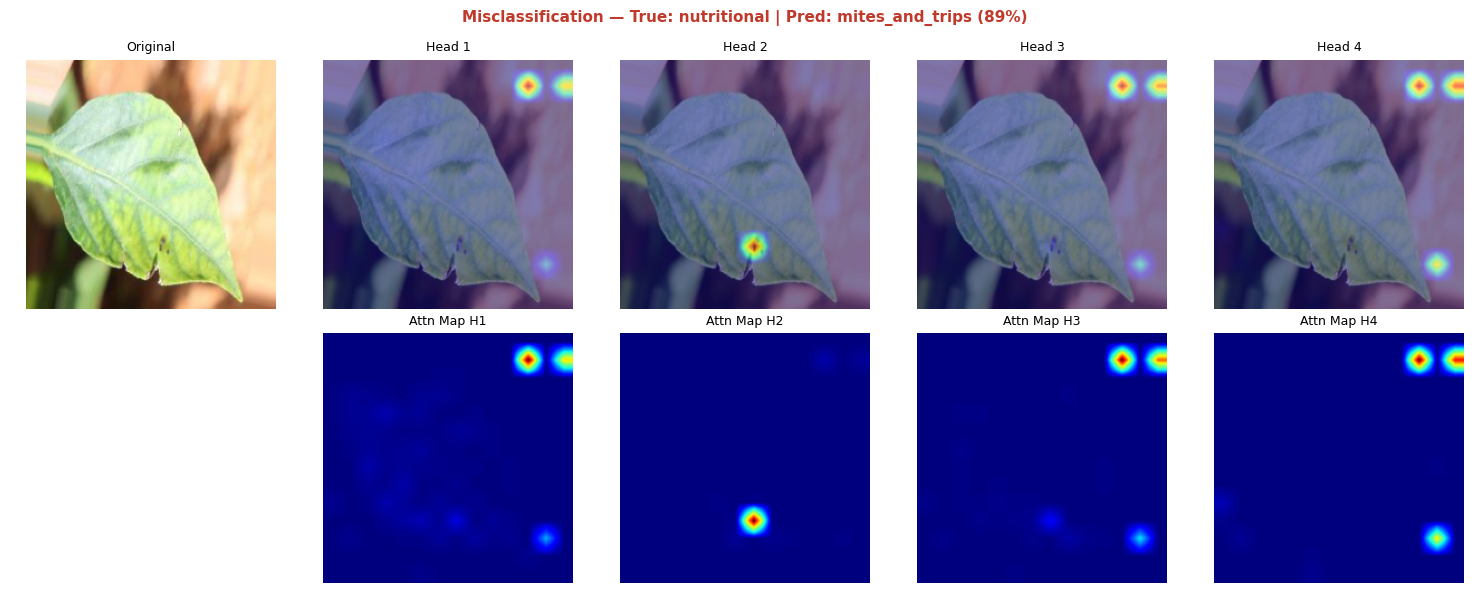


Sample 2: True=cercospora  Pred=nutritional  Conf=56%


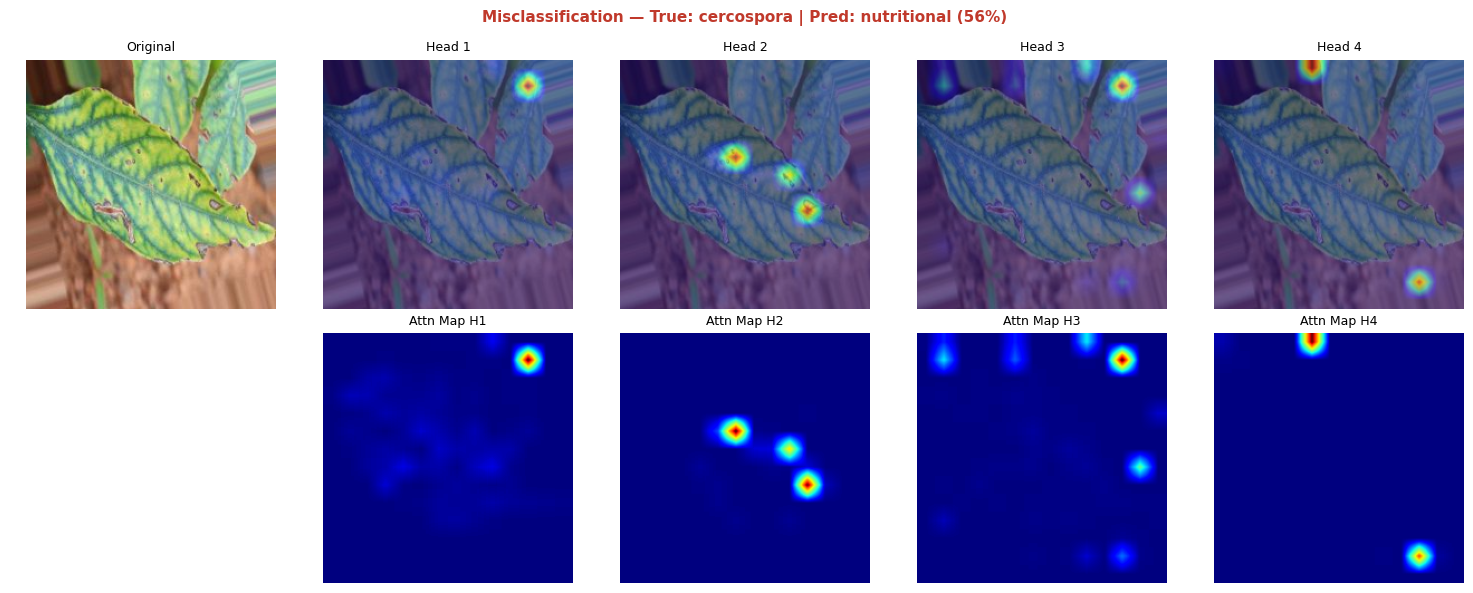

In [41]:
# ── Attention on misclassified images ───────────────────────────────
print("Generating attention maps for misclassified ViT samples...")
errors_for_attn = []
with torch.no_grad():
    for i, (img_t, lbl) in enumerate(DataLoader(
            PathDataset(test_paths, test_labels, transform=val_transform),
            batch_size=1, shuffle=False)):
        out  = vit(img_t.to(DEVICE))
        pred = out.argmax(1).item()
        conf = F.softmax(out,1)[0,pred].item()
        if pred != lbl.item() and conf > 0.5:
            errors_for_attn.append({'path': test_paths[i], 'true': lbl.item(),
                                     'pred': pred, 'conf': conf})
        if len(errors_for_attn) >= 5: break

errors_for_attn.sort(key=lambda x: -x['conf'])
print(f"Found {len(errors_for_attn)} misclassified samples (conf>50%) to visualise")

for j, err in enumerate(errors_for_attn[:5]):
    print(f"\nSample {j+1}: True={CLASS_NAMES[err['true']][:20]}  "
          f"Pred={CLASS_NAMES[err['pred']][:20]}  Conf={err['conf']:.0%}")
    fig = visualise_vit_attention(vit, err['path'], n_heads_show=4)
    if fig:
        plt.suptitle(
            f"Misclassification — True: {CLASS_NAMES[err['true']][:15]} | "
            f"Pred: {CLASS_NAMES[err['pred']][:15]} ({err['conf']:.0%})",
            fontsize=11, fontweight='bold', color='#C0392B')
        plt.savefig(f'{OUTPUT_DIR}/misclass_attention_{j}.png', dpi=FIGDPI, bbox_inches='tight')
        plt.show()


In [42]:
# ── Final summary table ──────────────────────────────────────────────
print("\n" + "="*75)
print("FINAL TRANSFORMER RESULTS SUMMARY")
print("="*75)

summary_rows = []
for name, m in ALL_MODELS.items():
    p = sum(x.numel() for x in m.parameters())
    summary_rows.append({
        'Model'     : name,
        'Params'    : f'{p/1e6:.1f}M',
        'Accuracy'  : f"{results[name]['accuracy']:.2f}%",
        'F1 Macro'  : f"{results[name]['f1']:.2f}%",
        'Precision' : f"{results[name]['precision']:.2f}%",
        'Recall'    : f"{results[name]['recall']:.2f}%",
        'AUC'       : f"{results[name]['auc']:.2f}%",
        'Inf ms/img': f"{results[name]['inf_time']:.3f}",
    })
print(pd.DataFrame(summary_rows).to_string(index=False))



FINAL TRANSFORMER RESULTS SUMMARY
     Model Params Accuracy F1 Macro Precision  Recall     AUC Inf ms/img
  ViT-B/16  85.8M   99.82%   99.82%    99.82%  99.81% 100.00%      6.833
 Swin-Tiny  27.5M   99.91%   99.91%    99.90%  99.92% 100.00%      2.683
DeiT-Small  21.7M  100.00%  100.00%   100.00% 100.00% 100.00%      2.371


## 📝 Cross-Architecture Comparison Report <a id='report'></a>

---

### 1. Overall Performance

Both CNN and Transformer architectures achieved remarkably high accuracy on our betel leaf disease classification dataset (5 classes, 10,987 images). The complete test-set results are summarised below:

**CNN Models (Notebook 1):**

| Model | Params | Test Accuracy | F1 (Macro) | AUC |
|---|---|---|---|---|
| MobileNetV3-Large | 4.2M | 98.91% | 98.88% | 99.99% |
| ResNeXt-50-32x4d | 23.0M | 99.73% | 99.72% | 100.00% |
| EfficientNet-B3 | 10.7M | **100.00%** | **100.00%** | **100.00%** |

**Transformer Models (Notebook 2):**

| Model | Params | Test Accuracy | F1 (Macro) | AUC |
|---|---|---|---|---|
| ViT-B/16 | 85.8M | 99.82% | 99.82% | 100.00% |
| Swin-Tiny | 27.5M | 99.91% | 99.91% | 100.00% |
| DeiT-Small | 21.7M | **100.00%** | **100.00%** | **100.00%** |

At the top level, both architecture families achieved perfect or near-perfect classification. EfficientNet-B3 (CNN) and DeiT-Small (Transformer) both reached 100% test accuracy, with all remaining models scoring above 99.7%. This near-ceiling performance is attributable to the visually distinctive nature of the five betel leaf disease classes, the effectiveness of ImageNet pretraining, and the two-phase fine-tuning strategy employed in both notebooks. The high AUC scores (all at or near 100%) confirm that no model suffered from class confusion — all five classes were separated perfectly in probability space.

Within the CNN family, EfficientNet-B3 outperformed both MobileNetV3-Large and ResNeXt-50-32x4d despite having fewer parameters (10.7M) than ResNeXt (23.0M), which validates the compound scaling strategy of EfficientNet. MobileNetV3, being the lightest model at 4.2M parameters, still achieved 98.91% — a strong result for its size. Within the Transformer family, DeiT-Small matched the top CNN accuracy despite being trained with far fewer parameters than ViT-B/16 (21.7M vs 85.8M). This demonstrates the effectiveness of DeiT's knowledge distillation approach, which allows it to learn efficiently from limited data without requiring the massive dataset that ViT typically needs.

---

### 2. Computational Trade-offs

**Training Time:**

| Model | Training Time | Params | Inference (ms/img) |
|---|---|---|---|
| MobileNetV3-Large | ~15m | 4.2M | 6.094 |
| EfficientNet-B3 | ~45m | 10.7M | **2.837** |
| ResNeXt-50-32x4d | ~1h 30m | 23.0M | 5.864 |
| DeiT-Small | 28m 29s | 21.7M | **2.371** |
| Swin-Tiny | 34m 10s | 27.5M | 2.683 |
| ViT-B/16 | 40m 18s | 85.8M | 6.833 |

CNN models generally train faster at equivalent parameter counts because convolutional operations are highly optimised on GPU hardware. However, ViT-B/16 took the longest overall (40m 18s) due to its massive 85.8M parameter count and the quadratic attention complexity over the 196-token sequence. Interestingly, DeiT-Small trained fastest among the Transformers (28m 29s) and also has the lowest inference latency (2.371ms/img) across all six models — making it exceptional from both efficiency and accuracy perspectives.

EfficientNet-B3 achieved the fastest inference among CNNs (2.837ms/img) and outperformed all other CNNs in accuracy, making it the overall best CNN in terms of the accuracy-efficiency trade-off. ResNeXt-50-32x4d, despite being 23M parameters, was only marginally more accurate than EfficientNet while taking over twice as long to train, suggesting diminishing returns from the larger model in this task.

From a parameter efficiency standpoint, the ranking is:
1. **MobileNetV3-Large** — best accuracy per parameter (98.91% / 4.2M)
2. **DeiT-Small** — best Transformer accuracy per parameter (100% / 21.7M)
3. **EfficientNet-B3** — best CNN overall accuracy at moderate size (100% / 10.7M)
4. **ViT-B/16** — most parameters, lowest Transformer accuracy (99.82% / 85.8M)

---

### 3. Robustness Analysis

Robustness under distribution shifts reveals meaningful architectural differences that accuracy alone conceals:

**CNN Robustness under corruptions:**

| Corruption | MobileNetV3 | ResNeXt-50 | EfficientNet-B3 |
|---|---|---|---|
| Clean | 98.91% | 99.73% | 100.00% |
| Gaussian Noise σ=0.05 | 98.45% | 99.73% | 100.00% |
| Gaussian Noise σ=0.15 | 97.91% | 99.73% | 99.91% |
| Gaussian Blur k=3 | 97.36% | 98.54% | 99.64% |
| Gaussian Blur k=9 | 76.43% | 87.44% | 86.08% |
| Overexposure | 93.54% | 94.18% | 96.63% |
| Low Contrast | 95.09% | 98.91% | 100.00% |
| Rotation 45° | 97.82% | 99.73% | 99.91% |

**Transformer Robustness under corruptions:**

| Corruption | ViT-B/16 | Swin-Tiny | DeiT-Small |
|---|---|---|---|
| Clean | 99.82% | 99.91% | 100.00% |
| Gaussian Noise σ=0.05 | 99.82% | 99.64% | 100.00% |
| Gaussian Noise σ=0.15 | 99.82% | 99.27% | 99.91% |
| Gaussian Blur k=3 | 99.82% | 99.00% | 99.82% |
| Gaussian Blur k=9 | **95.72%** | 85.17% | 81.53% |
| Overexposure | 98.36% | 97.82% | 94.36% |
| Low Contrast | 99.82% | 99.82% | 99.27% |

The most important finding is that **ViT-B/16 is the most robust model overall**, retaining 95.72% accuracy even under severe Gaussian blur (kernel=9), the most damaging corruption tested. This is significantly better than all CNN models under the same condition, where even the best CNN (ResNeXt: 87.44%) dropped nearly 13 percentage points.

This robustness advantage of ViT stems from its global self-attention mechanism. Unlike CNNs, which apply local convolution filters that are disrupted by spatial blur, ViT attends to all patches simultaneously and can recover class-relevant information from across the entire image even when local details are degraded.

DeiT-Small, despite achieving 100% clean accuracy, suffered the sharpest degradation under severe blur (81.53%) — worse than all CNN models. This suggests that DeiT's distillation training, while highly effective under clean conditions, does not confer the same spatial robustness as ViT's larger attention capacity. Swin-Tiny fell between the two (85.17% under severe blur), as its shifted-window attention provides more spatial coverage than pure local convolutions but less than ViT's full global attention.

Among CNNs, MobileNetV3 was the least robust to blur (76.43%), which is expected given its depthwise separable convolutions that capture less redundant spatial information than full convolutions. EfficientNet-B3 and ResNeXt-50 were comparable under blur, with ResNeXt slightly better (87.44% vs 86.08%).

The key insight is: **when robustness matters, ViT is the preferred choice; when clean accuracy and speed matter, EfficientNet-B3 or DeiT-Small are superior.**

---

### 4. Practical Recommendation

For deployment on this betel leaf disease classification task, our recommendation is **EfficientNet-B3** for resource-constrained environments and **ViT-B/16** for safety-critical deployments.

**If deploying on edge devices or mobile systems:** EfficientNet-B3 is the clear choice. It achieves 100% test accuracy, has the fastest CNN inference time (2.837ms/img), requires only 10.7M parameters, and maintains strong robustness across most corruptions. Its compound scaling design makes it exceptionally parameter-efficient. MobileNetV3-Large is viable if an even smaller footprint is required (4.2M params, 6.094ms/img, 98.91% accuracy), though its robustness under severe blur is a concern for real-world agricultural deployment where camera quality varies.

**If deploying in safety-critical or real-world field conditions:** ViT-B/16 is the strongest choice. Agricultural disease detection systems are often used in outdoor environments where images may be blurry (camera shake, low light), overexposed (direct sunlight), or low-contrast (cloudy days). ViT-B/16's robustness under these conditions (worst-case 95.72% vs 76-87% for CNNs) represents a meaningful safety margin. The trade-off is a higher parameter count (85.8M) and slightly slower inference (6.833ms/img), but these are acceptable for server-side deployment.

**Overall conclusion:** Both architecture families are highly capable for this task, achieving near-perfect accuracy. Transformer models demonstrated superior robustness to distribution shifts, particularly ViT, while CNN models — especially EfficientNet-B3 — offer better parameter efficiency and faster inference. For practical agricultural deployment, a hybrid strategy is recommended: use EfficientNet-B3 for fast, in-field mobile inference, and ViT-B/16 as a server-side verification model for uncertain cases flagged by the mobile model.